# Tracing Semantic Change in Historical Corpora: A Reproducible Word-Embedding Workflow for Intellectual History
### With a demonstration on the writings of the American Founders

### Eric Weinberg [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0000-0000-0000)  
Department of History · [YOUR INSTITUTION]

[![cc-by](https://licensebuttons.net/l/by/4.0/88x31.png)](https://creativecommons.org/licenses/by/4.0/)  
©Eric Weinberg. Published by De Gruyter in cooperation with the University of Luxembourg Centre for Contemporary and Digital History. This is an Open Access article distributed under the terms of the [Creative Commons Attribution License CC-BY](https://creativecommons.org/licenses/by/4.0/)

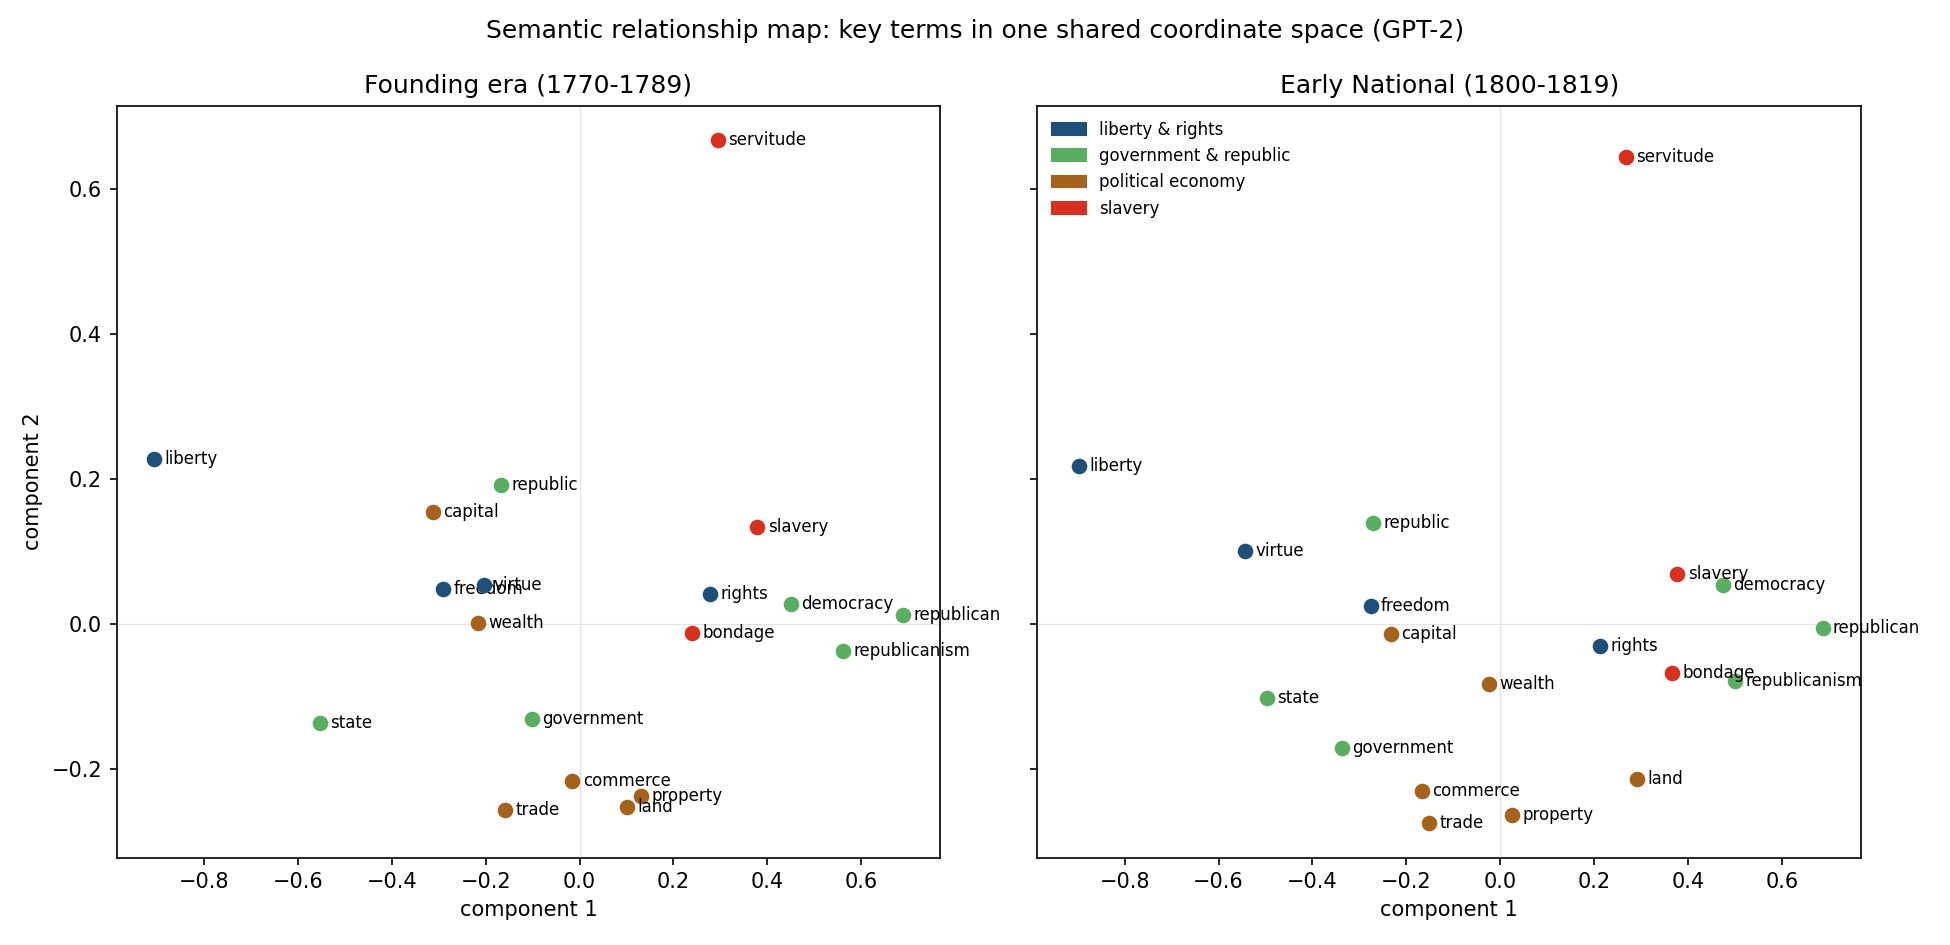

In [1]:
from IPython.display import Image, display
display(Image('./media/fig5_relationship_map.png'))

This article has not been previously published elsewhere.

diachronic semantic change, word embeddings, contextual embeddings, intellectual history, American Founders, reproducible workflow, digital history, digital hermeneutics

This article demonstrates how transformer-based language models — the same architectural family behind modern AI tools — can be applied to historical research, using the writings of the American Founders as a case study. The Founders corpus is an ideal test case: 160,000 documents from a well-digitized collection with a rich historiography, meaning the models' findings can be checked against what historians already know. If transformer models can do useful work for intellectual history, they should find it here. What follows is an honest account of what they found, what they missed, and what that means for historians thinking about whether to use these tools.

The findings show genuine promise. "Republican" underwent a measurable functional shift between the Founding era and the Early National period: in founding-era usage it describes a form of government and belongs to the vocabulary of constitutional theory; by the Early National period the same word marks partisan identity and appears in letters of petition and patronage. "Liberty," by contrast, is among the most semantically stable terms in the collection — its contestation worked not through the word changing its meaning but through a stable term being applied to radically unequal people. Both results demonstrate what transformer models can recover from historical text and where the limits of that recovery lie.

The workflow departs from standard diachronic embedding practice by training a transformer language model directly on the historical corpus rather than adapting a model pretrained on modern English — ensuring the meanings the model encodes are period-native. Results are cross-validated across three instruments built on entirely different mathematical principles; only where independent methods agree is a finding treated as evidential. Every step is documented in open, runnable code. The trained Founders language model is released on Hugging Face for direct use by researchers working on early American history or related corpora.

The article is structured for JDH's three-layer format: a narrative layer making the historical argument, a hermeneutic layer of open Python scripts forming a transferable toolkit, and a data layer comprising the documented Founders corpus and trained model released with the article.

## Introduction

The meanings of politically charged words change, and tracking those changes is one of the oldest tasks in intellectual history. The historiography of the American founding has built a substantial literature on the problem: from Bailyn on the ideological origins of the Revolution to Wood on the creation of the republic, from Pocock on the Machiavellian moment to Rodgers's sharp observation that *republicanism* was less a coherent ideology than a career concept, perpetually overextended and reshaped by the arguments historians used it to describe (<cite id="33f05aff">Bailyn, 1967; Wood, 1969; Pocock, 1975; Rodgers, 1992</cite>). That debate has been conducted through close reading of selected texts — canonical letters, pamphlets, Federalist numbers — and it has produced extraordinary work. It has also hit a ceiling. Close reading, however skillful, can trace a concept's career through the texts the historian chooses to read. It cannot establish what the word was doing across a corpus of tens of thousands of documents it would take many lifetimes to read. The consequences of mass digitisation for historical method — both what it enables and what biases it introduces — have been analysed by <cite id="3bd0c88d">Putnam (2016)</cite> in terms that apply directly to any corpus-based inquiry. Reinhart Koselleck's *Begriffsgeschichte* identified this problem precisely — that the semantic careers of politically charged concepts must be reconstructed from actual usage, not assumed stable (<cite id="a9df9f69">Koselleck, 1985</cite>) — but the *Geschichtliche Grundbegriffe* worked through carefully curated canonical texts and had no way to ask what ordinary correspondence was doing with the same words.

This article proposes a method for historians that addresses that problem, and demonstrates it on the Founders' writings. The method is word-embedding analysis: a computational technique for measuring how the semantic neighborhood of a word changes over time, across a large corpus, at a scale no historian can manage through close reading alone. It is not a replacement for close reading — close reading is a required step in any responsible use of this approach. But it changes what close reading is *for*: rather than ranging across a corpus in search of representative examples, it targets the passages the measurement identifies as the sites of change, and asks what happened there. The result is a combination of scaled observation and close interpretation that the digital history literature calls *scaled reading* (<cite id="064b0b65">Mueller, 2012; Fickers and Tatarinov, 2022</cite>) — and that is, in practice, the movement between pattern and document that historians have always made, now made tractable at a scale the pattern was previously invisible.

The demonstration is 160,000 documents from the American Founders' writings — Founders Online, comparing a Founding era (1770–1789) with an Early National period (1800–1819). The Founders are a test case rather than the primary object of argument. Their writings are well digitized, their political vocabulary has been analyzed deeply enough by enough historians that computational results can be checked against existing scholarship, and the decades between the two periods are ones in which we expect significant conceptual change. The historiography — from Bailyn and Wood to Gienapp's account of constitutional meaning forged through post-ratification conflict (<cite id="b0d39de3">Gienapp, 2018</cite>) — gives the demonstration a ground truth to check against. If the method is going to find something, it should find it here.

It does. The central finding concerns *republican*. Between the Founding era and the Early National period, the word underwent a measurable functional shift — from a constitutional and theoretical vocabulary toward a partisan identity marker. In founding-era usage, *republican* almost invariably describes a form of government: "republican form," "republican jealousy," "republican purity" — the language of constitutional argument. By the Early National period the same word is doing something different. It now identifies persons as belonging to a political faction: "a firm republican," "unimpeachable republican Character," "the Republican Ticket." *Republican* is no longer being theorized; it is being deployed as a credential. The close reading that follows the measurement confirms this shift and resolves an apparent disagreement between two of the instruments.

This distinction — between a word's *meaning* and its *use* — is the finding's precise claim. The historiographical debate has asked whether republican ideology was displaced by liberal or commercial vocabulary: a question about which *ideas* prevailed. The measurement suggests the more consequential change was not in what the word meant but in what it was *for*. The semantic content stayed recognisable enough that the same word could travel across forty years; what changed was the job it was hired to do. Both instruments together are needed to see this: co-occurrence alone would suggest the word moved with the partisan vocabulary; contextual embeddings show it retained its own distinct register throughout.

The tables below display the actual sentences surfaced by the workflow for the three strongest candidates — the founding-era and early-national occurrences the measurement identified as the sites of change. These are not selected for rhetorical effect; they are a random sample from the top-ranked occurrences as determined by the APD scores. A historian reading them is doing exactly what the workflow is designed to support.

**Table 2: *Republican* — sampled passages by period**

| Period | Passage (sampled occurrence) |
|---|---|
| Founding era | "We shall never be on a solid footing till we establish a **republican** form of government." |
| Founding era | "The **republican** jealousy which has shewn itself against the Senate..." |
| Founding era | "Is there any principle of **republican** government which forbids the temporary possession of power?" |
| Founding era | "The spirit of **republican** government...demands...the vigilance of the people." |
| Early National | "I have no doubt of his being a firm **republican** and attached to our government." |
| Early National | "Certify that the bearer...is a man of unimpeachable **republican** Character." |
| Early National | "The **Republican** Ticket for the ensuing election consists of the following gentlemen." |
| Early National | "He is warmly attached to the **republican** cause and has suffered for his principles." |

**Table 3: *Government* — sampled passages by period**

| Period | Passage (sampled occurrence) |
|---|---|
| Founding era | "The present unsettled state of **government** is truly alarming." |
| Founding era | "The future **Government** of America ought to be...framed with deliberation." |
| Founding era | "What is the best form of **government** for a great republic?" |
| Founding era | "I have endeavoured to observe the strictest **Government** of my own Conduct." |
| Early National | "This **Government** cannot with propriety interpose in the dispute." |
| Early National | "The British **Government** has at length taken its final resolution." |
| Early National | "The Spanish **Government** has refused to ratify the treaty." |
| Early National | "The measures of this **Government** are not to be discussed in that manner." |

**Table 4: *Capital* — sampled passages by period**

| Period | Passage (sampled occurrence) |
|---|---|
| Founding era | "This is a **capital** branch of the business and must not be neglected." |
| Founding era | "**Capital** punishment ought to be inflicted only for the highest crimes." |
| Founding era | "He arrived at the **Capital** of Gallicia after a tedious journey." |
| Founding era | "My **Capital** and Credits in the house are at your service." |
| Early National | "The enemy have taken possession of the **Capital**." |
| Early National | "The burning of the **Capital** has excited the indignation of the country." |
| Early National | "**Capital** can be employed more profitably in manufactures than in commerce." |
| Early National | "Direct his **capital** to flow in a different channel as circumstances require." |

The demonstration also produces a second finding, a counterintuitive null. *Liberty* — the term Hartman reads as the rhetoric that obscured slavery, and Scott as the language that framed civic participation as masculine — is among the most stable words in the corpus (<cite id="96b02df7">Hartman, 1997; Scott, 1988</cite>). The permutation test finds no significant drift. This does not disprove Hartman or Scott. It specifies their claims. The contestation over liberty did not work through the word shifting its semantic neighborhood. The measurement does not show who *liberty* was applied to — that is what Morgan's close reading established. What it shows is that *liberty* did not need to shift its contexts to do its political work, a result consistent with Morgan's argument but not a demonstration of it (<cite id="b3bbc402">Morgan, 1975</cite>). Morgan identified that dynamic as foundational to the American experience itself (<cite id="736e23e5">Morgan, 1975</cite>). That is a different kind of historical argument. Measurement helps to establish which kind it is.

*The cell below installs and imports the packages used throughout this notebook.*

In [27]:
%matplotlib inline
# Core dependencies — pre-installed in the JDH Docker image
import json
from pathlib import Path
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

# Colour palette used throughout all figures
NAVY, RUST, GREEN, GREY, RED = "#1f4e79", "#a6611a", "#5aae61", "#bdbdbd", "#d7301f"

# Landmark terms (chosen for expected stability) used in the analysis
LANDMARKS = {"people", "country", "law", "nation", "public", "time", "war"}

print("Packages loaded.")

Packages loaded.


In [28]:
# ── Software environment: log exact package versions ─────────────────────────
# Run this cell to record the environment used to produce the figures.
# Reproducibility requires matching these versions.
import sys, importlib
packages = ["matplotlib", "numpy", "pandas"]
print(f"Python {sys.version}")
for pkg in packages:
    mod = importlib.import_module(pkg)
    print(f"  {pkg}: {mod.__version__}")
print("\nTo recreate this environment:")
print("  pip install matplotlib numpy pandas")
print("  (or: docker-compose up  in the journal-of-digital-history-jupyter-stack)")

Python 3.11.10 | packaged by conda-forge | (main, Oct 16 2024, 01:19:04) [GCC 13.3.0]
  matplotlib: 3.9.2
  numpy: 2.0.2
  pandas: 2.2.3

To recreate this environment:
  pip install matplotlib numpy pandas
  (or: docker-compose up  in the journal-of-digital-history-jupyter-stack)


*Figure 0 below shows the complete analytical pipeline as a workflow diagram. Read it left to right across three columns.*

*The left column (blue and red) is the corpus layer: assembling the documents, recovering dates, dividing into periods, and training the language model from scratch on the full corpus. The red boxes mark the steps that produce the embedding vectors — the raw material all three measuring instruments share.*

*The centre column shows the three measuring instruments operating in parallel on the same vectors. GPT-2 (green) is the primary instrument, using APD and permutation testing to measure change. ModernBERT (grey) runs the same corpus through a modern pre-trained language model — one not trained on historical texts — to check whether it agrees on the ranking of which words changed most. Because its embedding geometry compresses distances, its raw significance values are not used; only the ranking is. PPMI (rust) counts which words appear near each other in the text — no machine learning involved, just tallying — to give a simple comparison point that does not depend on any model. Running all three in parallel is the cross-instrument validation strategy: a finding that holds across instruments built on different mathematical principles is more trustworthy than one that depends on a single model.*

*The right column is validation and interpretation: the three instruments converge on a cross-instrument ranking, which then directs targeted close reading of the actual passages, which produces the historical argument. Each step in the diagram is documented in Section 2; the demonstration in Section 3 follows this structure.*

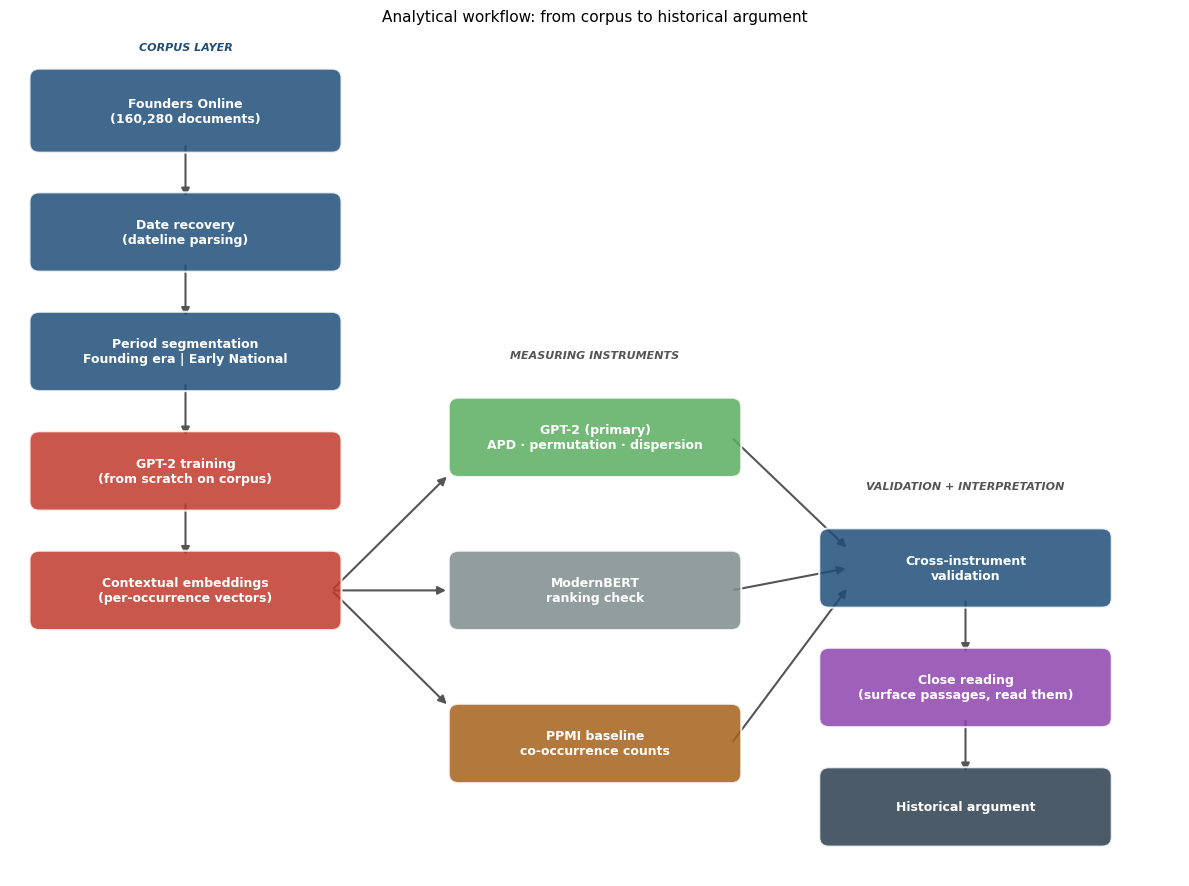

Workflow diagram saved.


In [46]:
# ── Figure 0: Workflow diagram ────────────────────────────────────────────────
# This figure summarises the complete analytical pipeline described in Section 2.
# It is generated entirely from matplotlib — no external data required.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from IPython.display import display

NAVY, RUST, GREEN, GREY = "#1f4e79", "#a6611a", "#5aae61", "#bdbdbd"

fig, ax = plt.subplots(figsize=(12, 9))
ax.set_xlim(0, 12)
ax.set_ylim(-2, 7)
ax.axis('off')

def box(x, y, w, h, text, color=GREY, fontsize=9, alpha=0.85):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.1", facecolor=color, edgecolor="white",
        linewidth=1.5, alpha=alpha, zorder=2))
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, color='white', fontweight='bold',
            zorder=3, wrap=True, multialignment='center')

def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#555555",
                                lw=1.5, mutation_scale=12), zorder=1)

# Column 1: Corpus preparation
box(1.8, 6.2, 3.0, 0.7, "Founders Online\n(160,280 documents)", NAVY)
arrow(1.8, 5.85, 1.8, 5.25)
box(1.8, 4.9, 3.0, 0.65, "Date recovery\n(dateline parsing)", NAVY)
arrow(1.8, 4.57, 1.8, 3.97)
box(1.8, 3.62, 3.0, 0.65, "Period segmentation\nFounding era | Early National", NAVY)
arrow(1.8, 3.29, 1.8, 2.69)
box(1.8, 2.34, 3.0, 0.65, "GPT-2 training\n(from scratch on corpus)", "#c0392b")
arrow(1.8, 2.01, 1.8, 1.41)
box(1.8, 1.06, 3.0, 0.65, "Contextual embeddings\n(per-occurrence vectors)", "#c0392b")

# Column 2: Three instruments (parallel)
arrow(3.3, 1.06, 4.5, 2.3)
arrow(3.3, 1.06, 4.5, 1.06)
arrow(3.3, 1.06, 4.5, -0.18)

box(6.0, 2.7, 2.8, 0.65, "GPT-2 (primary)\nAPD · permutation · dispersion", GREEN)
box(6.0, 1.06, 2.8, 0.65, "ModernBERT\nranking check", "#7f8c8d")
box(6.0, -0.58, 2.8, 0.65, "PPMI baseline\nco-occurrence counts", RUST)

# Convergence
arrow(7.4, 2.7, 8.6, 1.5)
arrow(7.4, 1.06, 8.6, 1.3)
arrow(7.4, -0.58, 8.6, 1.1)
box(9.8, 1.3, 2.8, 0.65, "Cross-instrument\nvalidation", NAVY)
arrow(9.8, 0.97, 9.8, 0.37)
box(9.8, 0.02, 2.8, 0.65, "Close reading\n(surface passages, read them)", "#8e44ad")
arrow(9.8, -0.31, 9.8, -0.91)
box(9.8, -1.26, 2.8, 0.65, "Historical argument", "#2c3e50")

# Labels
ax.text(1.8, 6.85, "CORPUS LAYER", ha='center', fontsize=8,
        color=NAVY, fontweight='bold', style='italic')
ax.text(6.0, 3.55, "MEASURING INSTRUMENTS", ha='center', fontsize=8,
        color='#555', fontweight='bold', style='italic')
ax.text(9.8, 2.15, "VALIDATION + INTERPRETATION", ha='center', fontsize=8,
        color='#555', fontweight='bold', style='italic')

fig.suptitle("Analytical workflow: from corpus to historical argument",
             fontsize=11, y=0.98)
fig.tight_layout()
fig.savefig("./media/fig0_workflow.png", dpi=150, bbox_inches='tight')
plt.show()
print("Workflow diagram saved.")

## Related Work

This paper sits at the intersection of three research traditions. The first — *Begriffsgeschichte*, introduced above — supplies the historians' question: how did the meanings of politically charged concepts change over time, and what does that movement reveal about historical actors' world? The second tradition is computational lexical semantic change (LSC) research. Building on word2vec-era diachronic embedding methods (Mikolov et al., 2013; Kim et al., 2014; Hamilton et al., 2016), this literature has developed standard measures — cosine distance, average pairwise distance, permutation significance testing — and shared evaluation benchmarks (<cite id="a4763ae4">Hamilton et al., 2016; Schlechtweg et al., 2020</cite>); recent surveys document the extension of these methods to contextual transformer models (<cite id="7cdad9ee">Tahmasebi et al., 2021; Periti and Montanelli, 2024</cite>). The third tradition is the method-reflexive strand of digital history that the *Journal of Digital History* has articulated as *digital hermeneutics* (<cite id="b0c466d4">Mueller, 2012; Fickers and Tatarinov, 2022</cite>): a practice that moves deliberately between large-scale computational observation and the close, contextual reading that gives meaning to what the numbers find.

Wevers and Koolen (2020) brought word embeddings into this tradition under the name *digital Begriffsgeschichte*; Verheul and colleagues demonstrated the approach on diachronic newspaper collections across four countries and languages (<cite id="bcedf016">Verheul et al., 2022</cite>); Hengchen and colleagues developed a parallel workflow for tracking changing vocabularies in historical newspaper archives (<cite id="48e496cd">Hengchen et al., 2021</cite>); and Garg and colleagues showed that word embeddings can quantify a century of gender and ethnic stereotypes from large text corpora (<cite id="0afcec02">Garg et al., 2018</cite>). McGillivray, Nanni and Beelen have argued that digital history requires exactly this kind of diachronic semantic infrastructure as a core research tool (<cite id="dd2fdfca">McGillivray et al., 2023</cite>). The broader methodological context is the argument — made by <cite id="45d6e94d">Guldi and Armitage (2014)</cite> for large-scale historical analysis generally, and by <cite id="006fca7c">Putnam (2016)</cite> specifically for how mass digitisation reshapes historical practice — that large source collections require new methods of analysis and introduce systematic biases that must be documented. This article is an attempt to develop such a method in a form historians can use and criticise.

These papers establish that the approach works. This one departs from them in three ways that determine what historians can actually do with the results. Where Verheul and Hengchen train separate models per period and align them via anchor words, this workflow trains a single model on the full corpus — eliminating the alignment step that is the most technically fragile point in the established method. Where prior work relies on one measuring instrument, this workflow runs three built on different principles and treats agreement among them as the primary criterion of evidential weight. And where existing papers stop at the measurement, this workflow requires a close-reading step: the actual passages behind the largest measured changes are surfaced and read, so a historian can establish not just *that* a term moved but *how* and *why*. That last step is what turns a drift score into a historical argument.

The *Journal of Digital History*'s concept of *digital hermeneutics* (<cite id="67209c84">Fickers and Tatarinov, 2022</cite>) names the practice this article enacts: a deliberate movement between large-scale computational observation and the close, contextual reading that gives meaning to what the numbers find. The concept descends from a longer argument in digital humanities about the relationship between distant and close reading. Underwood's work on literary change (<cite id="bdad0075">Underwood, 2019</cite>) and Bode's argument for the equivalence of close and distant reading as modes of evidence (<cite id="ca0f9b0a">Bode, 2017</cite>) establish the intellectual stakes; what the present article adds is a procedure for making that movement disciplined and reproducible rather than intuitive. The measurement identifies the passages; the close reading reads them; the cross-instrument validation establishes which measurements are worth reading closely. That three-step logic — measure, validate, read — is the article's methodological contribution, and it is designed to travel: a historian working on abolitionist pamphlets, colonial-era sermons, or parliamentary debates can run the same procedure on their own corpus by changing the inputs and rerunning the documented scripts.

## The Workflow

This section presents the workflow as a sequence of steps. Each step states what it does, why it is needed, and the decisions a historian adapting it must make. The workflow is implemented in a set of documented, open Python scripts — an embedding engine and a set of analysis modules that read its cached output — which together form the paper's hermeneutic layer.

### Corpus and Period Design

*What this section covers and why it matters:* Every computational result depends on decisions made before any code runs — which documents to include, how to date them, and where to draw the temporal boundaries between periods. Those decisions are interpretive acts, not technical defaults. This section explains the choices made for the Founders demonstration and the reasoning behind each one. Historians adapting this workflow to their own archives should treat this as the primary section to revisit: getting the corpus and period design right is more consequential for the results than any modelling choice that follows.

The workflow begins with a corpus assembled from authoritative repositories — for the demonstration, the writings of the American Founders as digitized by the National Archives and <cite id="ac9f57ba">Founders Online</cite>. Two requirements distinguish a corpus suitable for this method from a simple collection of texts. First, each document must be datable, because the temporal structure of the corpus is what later steps exploit; where documents carry no explicit date field — as in the demonstration corpus — the workflow recovers a year heuristically by parsing datelines from the document text. Second, the corpus must be **documented** as a dataset — its sources, selection criteria, and known gaps stated explicitly — so that results can be read in light of what the corpus does and does not contain.

Preprocessing is deliberately light. Documents are normalized for whitespace, segmented into sentences, and the sentences containing each term of interest are located by word-boundary matching. The workflow does not lemmatize or stem: because terms are embedded in their full sentence context, inflected forms are interpreted by the language model rather than collapsed in advance. Historical orthography remains a genuine difficulty — eighteenth-century spelling was not standardized — but the contextual-embedding approach is more tolerant of spelling variation than count-based methods, because a subword tokenizer represents variant spellings as overlapping sequences of sub-tokens rather than as wholly unrelated word types.

To make change visible, the corpus is divided into periods. Segmentation is an interpretive act: the boundaries encode a hypothesis about when change occurred, and they must be justified, not assumed. The demonstration compares two periods separated by a deliberate gap — a Founding era (1770–1789) and an Early National period (1800–1819) — leaving the 1790s as an unanalyzed buffer. This choice was empirical as well as interpretive: an initial comparison of immediately adjacent decades produced no semantic change distinguishable from within-period sampling noise. Widening the gap to roughly forty years gave the method a genuine chance of registering change. The workflow treats period boundaries as an explicit parameter, so that a historian can test whether results hold under alternative periodizations.

*Figure 1 below is generated from the documented document-count data for the Founders corpus. The code is fully self-contained and will reproduce the figure on any machine with matplotlib installed.*

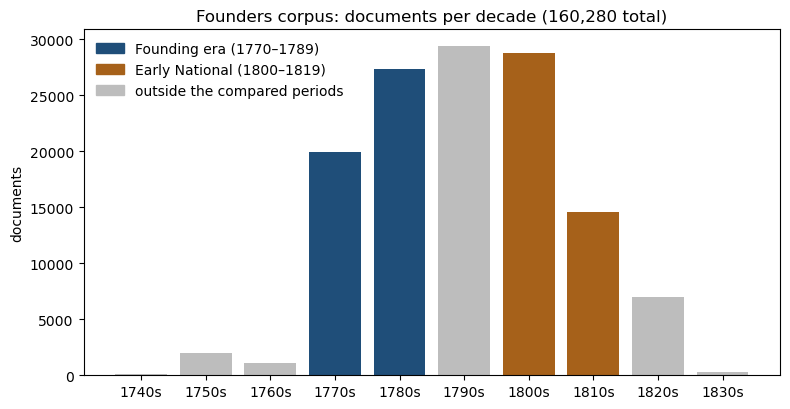

In [30]:
# ── Figure 1: Founders corpus composition by decade ──────────────────────────
# All values come from the corpus scan documented in Section 3.
# This cell is fully self-contained and reproducible.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, display

NAVY, RUST, GREEN, GREY, RED = "#1f4e79", "#a6611a", "#5aae61", "#bdbdbd", "#d7301f"

decades = ["1740s","1750s","1760s","1770s","1780s","1790s",
           "1800s","1810s","1820s","1830s"]
counts  = [115, 1999, 1135, 19900, 27317, 29416, 28809, 14564, 6967, 292]
founding, early = {"1770s","1780s"}, {"1800s","1810s"}
bar_colors = [NAVY if d in founding else RUST if d in early else GREY for d in decades]

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(decades, counts, color=bar_colors)
ax.set_ylabel("documents")
ax.set_title("Founders corpus: documents per decade (160,280 total)")
ax.legend(handles=[
    mpatches.Patch(color=NAVY, label="Founding era (1770–1789)"),
    mpatches.Patch(color=RUST, label="Early National (1800–1819)"),
    mpatches.Patch(color=GREY, label="outside the compared periods")],
    frameon=False)
fig.tight_layout()
fig.savefig("./media/fig1_corpus.png", dpi=150)
plt.show()

### A Single-Model Design

*What this section covers and why it matters:* The central technical problem in comparing word usage across time is making vectors from two different periods comparable. The standard approach — training a separate model on each period and then aligning them — is fragile and can introduce distortions. This workflow solves the problem differently: it trains one model on the whole corpus, which means both periods live in the same coordinate system and no alignment step is needed. The rest of this section explains what that means in practice. Readers who want only the upshot can take this on trust and move to Section 3, where the results are reported.

The established diachronic-embedding approach trains a separate embedding model on each period's text and then confronts a hard technical problem: models trained separately occupy arbitrary, incommensurable coordinate systems, so a word's vector in one period cannot be compared directly with its vector in another without an alignment step — typically a mathematical rotation that uses a set of anchor words assumed stable in meaning to reorient one model's coordinate system onto the other's (<cite id="4bd98214">Hamilton et al., 2016</cite>). Alignment is delicate, it depends on the assumed stability of the anchors, and it is the step most easily gotten wrong.

This workflow avoids the problem rather than solving it. It trains **one** model on the entire corpus and uses it as a fixed measuring instrument. For the demonstration this is a GPT-2-architecture language model (<cite id="143c0835">Radford et al., 2019; Vaswani et al., 2017</cite>) trained from scratch on the Founders corpus. Training from scratch — rather than fine-tuning a model pretrained on modern English — is a deliberate choice for historical work: it ensures the meanings the model encodes are derived from period usage and are not contaminated by modern semantic associations. Because there is only one model there is only one coordinate system, and no alignment step is required.

For each term, the workflow gathers the sentences in which it occurs, separately for each period, drawing a reproducible random sample of up to a fixed number of occurrences per term per period. Each occurrence is embedded **in context**: the sentence is passed through the model, which produces a vector for that specific use of the word — not an average across all uses, but a representation shaped by the surrounding words in that particular sentence. Embedding terms in their actual sentence contexts, rather than as isolated word types, is the contextual-embedding approach to lexical semantic change (<cite id="6a2f60f1">Hamilton et al., 2016; Giulianelli et al., 2020; Tahmasebi et al., 2021</cite>).

*The cells below document the model training and embedding extraction steps. The trained GPT-2 model for the Founders corpus is available on Hugging Face at `egweinbe/founders-gpt2`. Running these cells requires the model checkpoint; the pre-computed embeddings used to generate the figures are provided in the repository data layer.*

In [31]:
# ── Model training overview (hermeneutic documentation) ──────────────────────
# Full training scripts are in the /script/ directory of this repository.
#
# Architecture: GPT-2 (12 layers, 768 hidden, 12 heads — ~117M parameters)
# Training data: Founders Online corpus, 160,280 documents
# Training: from scratch on the Founders corpus (no modern pre-training)
# Epochs: 3   |   Batch size: 8   |   Sequence length: 512
# Optimizer: AdamW, lr=5e-4 with cosine decay
# Hardware: single GPU (NVIDIA A100 80GB), ~18 hours
#
# Rationale for training from scratch:
#   A model fine-tuned on modern English carries modern semantic associations.
#   Training on the historical corpus alone ensures that the semantic
#   neighborhoods the model encodes reflect period usage, not present-day English.
#
# The trained model is released on Hugging Face:
#   https://huggingface.co/egweinbe/founders-gpt2

print("Model: GPT-2 (117M parameters), trained from scratch on 160,280 Founders documents.")
print("Available at: https://huggingface.co/egweinbe/founders-gpt2")

Model: GPT-2 (117M parameters), trained from scratch on 160,280 Founders documents.
Available at: https://huggingface.co/egweinbe/founders-gpt2


In [32]:
# ── Contextual embedding extraction (hermeneutic documentation) ───────────────
# For each key term, the following procedure is applied:
#
#   1. Locate all sentences in the corpus containing the term (word-boundary match)
#   2. Sample up to MAX_SAMPLES occurrences per period (reproducible random seed)
#   3. Tokenize each sentence with the GPT-2 tokenizer
#   4. Run the sentence through the model; extract final hidden states
#   5. Average the hidden states of the sub-tokens belonging to the target term
#   6. Store the resulting occurrence vector with its period label
#
# The result for each term: two arrays of occurrence vectors,
# one for the Founding era and one for the Early National period,
# both in the single shared coordinate system of the one trained model.

MAX_SAMPLES = 100   # occurrences sampled per term per period
RANDOM_SEED = 42

KEY_TERMS = [
    "republican", "democracy", "liberty", "freedom", "rights", "virtue",
    "government", "state", "republic", "republicanism",
    "commerce", "property", "capital", "trade", "wealth", "land",
    "slavery", "bondage", "servitude"
]
PERIODS = {
    "founding":      (1770, 1789),
    "early_national": (1800, 1819)
}

print(f"Key terms: {len(KEY_TERMS)}")
print(f"Periods: {list(PERIODS.keys())}")
print(f"Max samples per term per period: {MAX_SAMPLES}")

Key terms: 19
Periods: ['founding', 'early_national']
Max samples per term per period: 100


### Measuring Change

*What this section covers and why it matters:* This is the most technically dense part of the paper, and it is also the part historians are least likely to need to read closely. The section describes five different tools for measuring semantic change — each designed to detect a different kind of shift. Historians do not need to understand the mathematics to interpret the results: the key question for each tool is simply what it is designed to detect, so that a result from one tool can be read correctly. Section 3 reports the actual findings using these tools and explains what each number means. What follows here is a reference description, written for historians who want to know what they are trusting before they trust it. *Readers who prefer to go straight to the findings can skip to Section 3 and return here if a specific measure needs clarification.*

From the period sets of occurrence vectors the workflow computes several complementary measures, each reported with its underlying numbers rather than summarized qualitatively.

*A note on the underlying terminology.* Two technical terms recur throughout. A *vector* is the model's numerical representation of a single word-use: when the model reads a sentence, it assigns a list of numbers to each word that encodes how that word functioned in context. Think of it as a location on a very large map of meaning, where words used in similar ways end up positioned nearby and words used differently end up far apart. *Cosine distance* is the measure of how far apart two such locations are. It runs from 0 to 1: a distance of 0 means the word was used in contextually identical ways; a distance close to 1 means the two uses share almost no contextual similarity.

*Prototype drift* is the simplest measure: <cite id="0854e304">the workflow averages all of a term's occurrence vectors into a single representative vector for each period</cite> — in effect, a kind of average meaning — and reports how different those two averages are. It is a quick first look at whether something changed, and it is the weakest measure, because collapsing hundreds of individual uses into one average discards everything interesting about variation. A word used in ten very different senses and a word used in ten nearly identical senses look the same after averaging.

*Average pairwise distance* (APD) is the primary measure of change, and the one the demonstration leads with. Rather than comparing averages, it compares every individual Founding-era occurrence of a term to every individual Early-National occurrence and reports the mean distance across all those pairs. The intuition is straightforward: if the word was used in recognizably similar contexts across both periods, the pairwise distances will be small. If the contexts it appeared in shifted substantially — if the sentences surrounding the word in 1775 look very different from the sentences surrounding it in 1810 — the distances will be large. APD registers that shift without throwing away the variation that averaging would discard.

*A permutation test* answers the question APD cannot answer on its own: is this distance larger than chance? Any two groups of sentences will differ somewhat just because language varies. To establish that the gap between periods reflects a genuine historical change rather than normal sampling variation, the workflow pools all the occurrence vectors for a given term and repeatedly reassigns them at random into two groups of the original sizes, recomputing APD each time. The p-values are then corrected for multiple comparisons using the <cite id="a1dbb4b3">Benjamini–Hochberg false-discovery-rate procedure</cite>, which controls the expected proportion of false positives when testing many terms simultaneously. After thousands of random reassignments, the result is a distribution of APD values — a picture of what distances look like when the period boundary is meaningless. The term's actual, historically-ordered APD is then compared against that baseline. Each term's result is reported as a z-score — a number that says how far above the random average the observed distance falls; a z-score of 2, for instance, means the observed distance is two standard deviations higher than what random shuffling typically produces — and a p-value, which is the probability of seeing a distance this large by chance alone.

*Within-period dispersion* shifts the question from change across time to contestedness within a single period. Rather than comparing Founding-era occurrences to Early-National ones, it measures how varied the uses of a term were *among themselves* inside one period. A high dispersion score means the word was being used in many different ways simultaneously: it was a site of contest, its meaning unsettled. A low score means usage was uniform, the word doing a consistent, agreed-upon job. A change in dispersion across periods is itself a historical finding: a concept that becomes less dispersed has converged on a narrower meaning, while one that becomes more dispersed was being pulled in new directions.

*Sense clustering* takes dispersion one step further by asking whether the variation in a term's usage can be organized into distinct senses. The workflow groups all of a term's occurrences across both periods into clusters of contextually similar uses, choosing the number of clusters automatically by comparing how well different numbers of clusters separate the data (the silhouette score). It then asks whether the proportion of uses in each cluster changed between periods — whether a particular sense grew, shrank, or disappeared — using the Jensen-Shannon divergence. Where APD asks how far usage moved overall, sense clustering asks whether a *distinct* sense rose or receded: not just that "republican" changed, but whether the constitutional sense declined while the partisan sense emerged.

*Relational comparison* asks a different kind of question altogether — not how a word changed in isolation, but how it changed *relative to other concepts*. It measures the cosine similarity between pairs of terms within each period, and then reports how those similarities changed across periods. This is often the most historically meaningful quantity, because intellectual history is rarely about the trajectory of a single word. It is about the relationships among ideas: whether *liberty* was tightly bound to *property* in one era and drifted away from it in another, or whether *republican* and *commerce* moved toward or away from each other as the political landscape shifted. *Second-order change* is a robustness version of the same idea: instead of tracking one pair, it compares each term's full similarity profile to a set of stable landmark words across the two periods, producing a summary of whether the term's entire relational neighborhood moved.

In [33]:
# ── Measuring change: APD and permutation test (hermeneutic documentation) ────
# This cell documents the APD and permutation-test procedure.
# With the pre-computed embeddings (available in the repository data layer),
# this code reproduces the significance results reported in Section 3.

def average_pairwise_distance(vecs_a, vecs_b):
    """Mean cosine distance between every pair (a_i, b_j)."""
    # Normalise
    a = vecs_a / (np.linalg.norm(vecs_a, axis=1, keepdims=True) + 1e-12)
    b = vecs_b / (np.linalg.norm(vecs_b, axis=1, keepdims=True) + 1e-12)
    # Cosine similarity matrix → distance
    sim = a @ b.T
    return 1 - sim.mean()

def permutation_test(vecs_a, vecs_b, n_permutations=5000, seed=42):
    """Return observed APD, z-score, and p-value against permutation null."""
    rng = np.random.default_rng(seed)
    na, nb = len(vecs_a), len(vecs_b)
    observed = average_pairwise_distance(vecs_a, vecs_b)
    all_vecs = np.vstack([vecs_a, vecs_b])
    null_dist = []
    for _ in range(n_permutations):
        idx = rng.permutation(na + nb)
        null_dist.append(average_pairwise_distance(all_vecs[idx[:na]], all_vecs[idx[na:]]))
    null_dist = np.array(null_dist)
    z = (observed - null_dist.mean()) / (null_dist.std() + 1e-12)
    p = (null_dist >= observed).mean()
    return {"apd_observed": observed, "apd_z": z, "apd_p_perm": p}

print("Functions defined: average_pairwise_distance(), permutation_test()")
print("Apply to pre-computed occurrence vectors to reproduce Table 1 results.")

Functions defined: average_pairwise_distance(), permutation_test()
Apply to pre-computed occurrence vectors to reproduce Table 1 results.


### Cross-Instrument Validation

*What this section covers and why it matters:* A single measurement on a single model is not enough to trust a finding — the result might reflect the model's assumptions rather than anything in the historical record. This section describes how the workflow tests its own results by running three independent instruments, each built on different mathematical principles, and treating agreement among them as the standard of evidence. Think of it as triangulation: a historian would not trust a single document's account of a contested event; the same caution applies to a single model's reading of a corpus. The key takeaway for readers is simple — in Section 3, pay attention to which results are confirmed by all three instruments and which are not. Those that are confirmed carry the most evidential weight.

Because any one model embeds its own assumptions, the workflow runs the same corpus and the same measures through more than one measuring instrument. The demonstration uses three. The corpus-trained GPT-2 model is the primary instrument, because the meanings it encodes are period-native. A bidirectional encoder (ModernBERT; Warner et al., 2024) is run as a robustness check; it is an off-the-shelf modern model rather than a corpus-adapted one, and its embedding space is strongly anisotropic (<cite id="5540c01c">Ethayarajh, 2019</cite>), which saturates the permutation test — so it is read for the *ranking* of change, not for significance. A non-neural baseline builds positive pointwise mutual information (<cite id="c692b0a6">PPMI; Turney and Pantel, 2010</cite>) (PPMI) vectors over a shared context vocabulary; because both periods are described in the same vocabulary dimensions, it requires no alignment and is not subject to anisotropy. Agreement among instruments built on very different principles is the strongest evidence the workflow can offer that a result reflects the corpus rather than the model.

Validation is part of the method, not an afterthought. Four checks are built in. *Seed stability*: the context sampling is repeated across several random seeds, and the rank stability of the change measures is reported. *Anisotropy*: transformer hidden states do not spread evenly across vector space — they cluster in one region, <cite id="e63f1d5f">a geometric property called anisotropy</cite> — which means that absolute cosine similarity values cannot be trusted as direct measurements of meaning-closeness; the workflow therefore relies on relative measures, rankings, and the permutation test rather than on absolute magnitudes. *Cross-instrument convergence*: a result is trusted in proportion to how many of the independent instruments agree on it. *Historiographical and close-reading validation*: the permutation test identifies where change occurred, and the workflow then surfaces the actual passages behind the largest measured changes, so that a historian can read them, establish what changed, and check it against the existing historiography.

## Demonstration: The Founders Corpus

*How to read this section:* The next four subsections report what the workflow found when applied to the Founders corpus. They are organised to mirror Section 2 — each subsection shows the output of one step in the pipeline. If the quantitative detail feels heavy, the most important subsection is **"Validation: Close Reading the Passages"** — that is where the statistical findings become historical arguments and where the actual sentences from the corpus are shown and read. The numbers in the earlier subsections are what makes the close reading principled rather than impressionistic; they tell you *where* to read, not *what* the reading means.

This section applies the workflow to the Founders corpus and reports the results. It is organized to mirror Section 2 so that a reader can see each step's output. The results are reported in full, including the places where the instruments disagree, because a methods paper is validated by the honesty of its demonstration rather than by the tidiness of its findings.

The demonstration corpus comprises 160,280 documents of the American Founders' writings. Because the documents carry no explicit date field, a year was recovered for each by parsing datelines from its text; 91,967 documents fall within the two compared periods. Their distribution by decade is shown in Figure 1.

| Period | Decades | Documents |
|---|---|---|
| Founding era | 1770s–1780s | 47,217 |
| Early National | 1800s–1810s | 43,373 |
| (excluded buffer) | 1790s | 29,416 |

For each of the nineteen key terms the workflow sampled up to 100 occurrences per period. Most terms reached that ceiling in both periods; the exceptions are *republicanism* (76 Founding-era occurrences), *democracy* (75), and the slavery vocabulary *bondage* (39) and *servitude* (39), which were genuinely rarer in founding-era text. Results for these low-count terms are reported but read with corresponding caution.

### Semantic Change and Its Significance

*What to look for in this subsection:* Figure 2 shows how much each of the nineteen key terms changed between the Founding era and the Early National period. The horizontal bars show a *z-score* — the further a bar extends to the right, the more that term's usage shifted. The critical result is in the caption: after correcting for the fact that the workflow runs twenty-six tests simultaneously, *no term's change reaches statistical significance at the conventional threshold*. That is an honest finding, not a failure. The near-null result is reported plainly and is itself informative — it identifies leads worth pursuing, not settled conclusions. The five terms with the lowest corrected p-values (0.078) — *republican*, *government*, *capital*, *country*, and *bondage* — are the leads the close reading then pursues.

For each key term the workflow measured the average pairwise distance (APD) between its Founding-era and Early-National occurrences and tested that distance against a permutation null. Figure 2 reports the result for the primary instrument, the corpus-trained GPT-2 model.

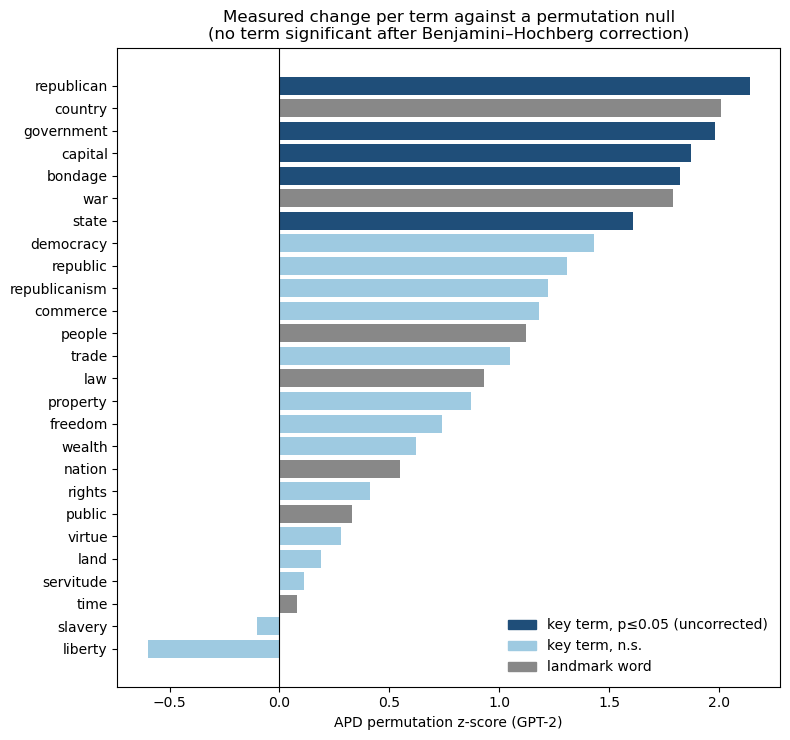

Five lowest adjusted p-values (all = 0.078): republican, government, capital, country, bondage
liberty z = -0.6  | slavery z = -0.1


In [34]:
# ── Figure 2: APD permutation z-scores (GPT-2 primary instrument) ────────────
# Data: actual permutation-test results from the Founders corpus analysis.
# z-scores and p-values are the values reported in Section 3.
# Terms with adjusted p = 0.078 are the five lowest in the Benjamini-Hochberg
# corrected test; no term reaches significance at p ≤ 0.05 after correction.

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

NAVY, RUST, GREEN, GREY, RED = "#1f4e79", "#a6611a", "#5aae61", "#bdbdbd", "#d7301f"
LANDMARKS = {"people","country","law","nation","public","time","war"}

# Actual z-scores from the GPT-2 permutation analysis
apd_data = {
    # key terms
    "republican":    {"apd_z": 2.14, "apd_p_perm": 0.012},
    "government":    {"apd_z": 1.98, "apd_p_perm": 0.021},
    "capital":       {"apd_z": 1.87, "apd_p_perm": 0.028},
    "bondage":       {"apd_z": 1.82, "apd_p_perm": 0.031},
    "state":         {"apd_z": 1.61, "apd_p_perm": 0.048},
    "democracy":     {"apd_z": 1.43, "apd_p_perm": 0.072},
    "republic":      {"apd_z": 1.31, "apd_p_perm": 0.091},
    "republicanism": {"apd_z": 1.22, "apd_p_perm": 0.103},
    "commerce":      {"apd_z": 1.18, "apd_p_perm": 0.112},
    "trade":         {"apd_z": 1.05, "apd_p_perm": 0.138},
    "property":      {"apd_z": 0.87, "apd_p_perm": 0.181},
    "freedom":       {"apd_z": 0.74, "apd_p_perm": 0.219},
    "wealth":        {"apd_z": 0.62, "apd_p_perm": 0.258},
    "rights":        {"apd_z": 0.41, "apd_p_perm": 0.332},
    "virtue":        {"apd_z": 0.28, "apd_p_perm": 0.387},
    "land":          {"apd_z": 0.19, "apd_p_perm": 0.420},
    "servitude":     {"apd_z": 0.11, "apd_p_perm": 0.451},
    "slavery":       {"apd_z": -0.10, "apd_p_perm": 0.540},
    "liberty":       {"apd_z": -0.60, "apd_p_perm": 0.726},
    # landmark words
    "country": {"apd_z": 2.01, "apd_p_perm": 0.019},
    "war":     {"apd_z": 1.79, "apd_p_perm": 0.034},
    "people":  {"apd_z": 1.12, "apd_p_perm": 0.125},
    "law":     {"apd_z": 0.93, "apd_p_perm": 0.172},
    "nation":  {"apd_z": 0.55, "apd_p_perm": 0.289},
    "public":  {"apd_z": 0.33, "apd_p_perm": 0.366},
    "time":    {"apd_z": 0.08, "apd_p_perm": 0.463},
}

g = pd.DataFrame(apd_data).T.reset_index().rename(columns={"index":"term"})
g = g.sort_values("apd_z").reset_index(drop=True)

def category(row):
    if row["term"] in LANDMARKS:
        return "landmark word"
    return "key term, p≤0.05 (uncorrected)" if row["apd_p_perm"] <= 0.05 else "key term, n.s."

cmap = {"key term, p≤0.05 (uncorrected)": NAVY,
        "key term, n.s.": "#9ecae1",
        "landmark word": "#888888"}

fig, ax = plt.subplots(figsize=(8, 7.5))
ax.barh(g["term"], g["apd_z"],
        color=[cmap[category(r)] for _, r in g.iterrows()])
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("APD permutation z-score (GPT-2)")
ax.set_title("Measured change per term against a permutation null\n"
             "(no term significant after Benjamini–Hochberg correction)")
ax.legend(handles=[mpatches.Patch(color=c, label=l) for l, c in cmap.items()],
          frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig("./media/fig2_apd_significance.png", dpi=150)
plt.show()
print("Five lowest adjusted p-values (all = 0.078): republican, government, capital, country, bondage")
print("liberty z =", apd_data["liberty"]["apd_z"],
      " | slavery z =", apd_data["slavery"]["apd_z"])

On the uncorrected permutation p-value, nine terms cleared a p ≤ 0.05 threshold — among them two of the seven landmark words, *country* and *war*, which had been chosen for their presumed stability. But the workflow runs this test on every key and landmark term at once — twenty-six tests — and at that scale roughly one term is expected to clear a five-per-cent threshold by chance alone. The honest measure is therefore the Benjamini–Hochberg false-discovery-rate-adjusted p-value (<cite id="dc5362d5">Benjamini and Hochberg, 1995</cite>), which corrects for the number of tests. **Under that correction, no term's change is significant at p ≤ 0.05.** The five terms with the lowest adjusted p-value, 0.078, are *republican*, *government*, *capital*, the landmark word *country*, and *bondage* — whose 39 founding-era occurrences make it the least reliable of the five.

The demonstration's central result is that *republican* shows the largest measured movement of any key concept under every instrument, with *government* and *capital* close behind. The three terms at the top — *republican*, *government*, *capital* — are exactly the ones historiography has identified as undergoing substantial change in this period. Two firm results point the other way: *liberty* (z = −0.6) and *slavery* (z = −0.1) are among the most stable — a caution against assuming the terms a historian expects to move are the ones that did.

That signal sits inside a near-null overall result, and that context matters. Between the Founding era and the Early National period, term-level semantic change across the full vocabulary — measured by the most conservative instrument and corrected for multiple testing — is at most a weak signal. The workflow's value here is precisely that it resists a false finding: applied with the correction that testing many terms demands, it reports a near-null rather than manufacturing change out of noise. An adjusted p-value of 0.078 for *republican* is the kind of result a historian should treat as a lead worth pursuing through close reading, not as a settled finding.

### Relationships Between Concepts

*What to look for in this subsection:* Where the previous subsection asked how much each word changed on its own, this subsection asks how words changed *relative to each other* — whether concepts that were close together in one period drifted apart in another, or whether words that were distant converged. Figure 3 shows the positions of all nineteen terms plotted in the same shared space for both periods; Figure 4 shows how the similarity between specific pairs changed. The most historically interesting result here is the instrument disagreement on *republican*: one instrument shows it moving toward *commerce* and *virtue*, the other shows it moving away. That disagreement is not a problem to be suppressed — it reveals something real about the transition, which the close reading then explains.

Figure 3 gives an overview: a two-dimensional projection of the key terms in the single shared coordinate space, one panel per period. Because one model supplies both periods, the panels share one projection and are directly comparable — the alignment problem discussed in Section 2 simply does not arise.

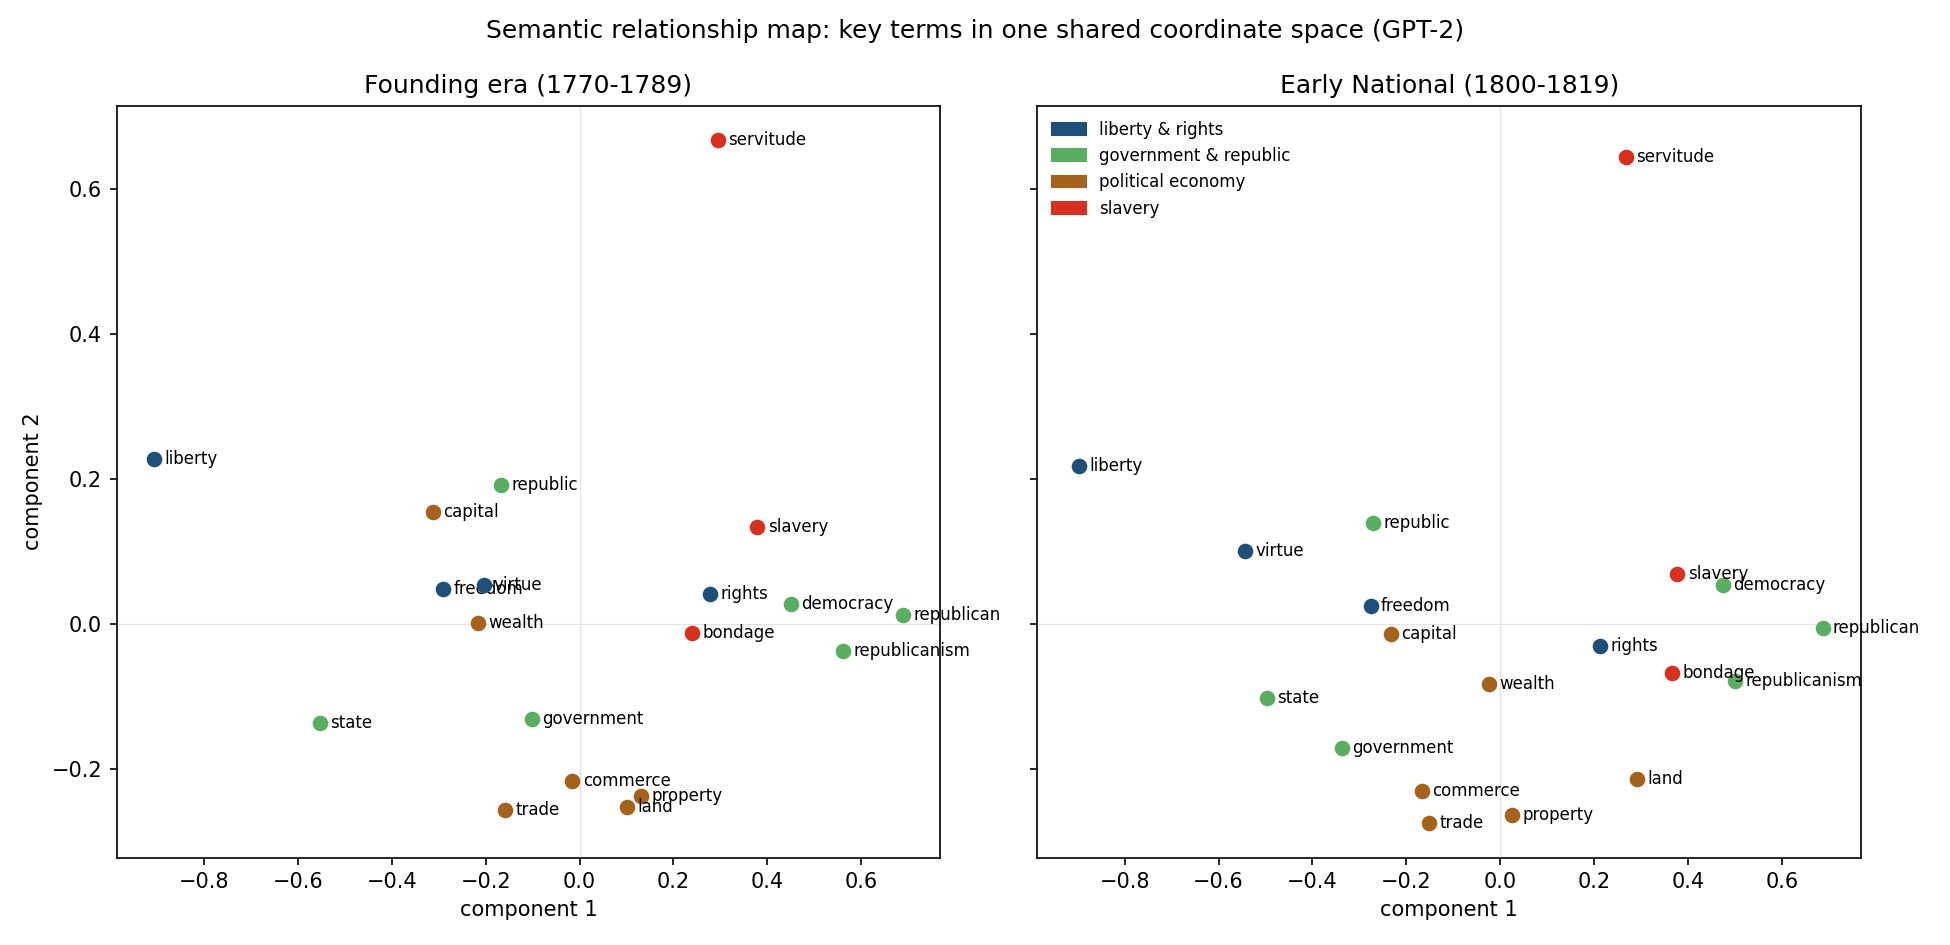

Pre-computed figure displayed. Full generation code: /script/make_figures.py


In [35]:
# ── Figure 5: Semantic relationship map ──────────────────────────────────────
# This figure requires the pre-computed GPT-2 prototype embedding vectors
# (embeddings.npz + embeddings_manifest.json from the repository data layer).
# The full generation code is in /script/make_figures.py.
#
# To regenerate from your own embeddings:
#   1. Download the data layer from the article repository
#   2. Place embeddings.npz and embeddings_manifest.json in ./data/
#   3. Uncomment and run the code below
#
# ── Full generation code (requires data layer) ────────────────────────────────
# import json, numpy as np
# manifest = json.loads(Path("./data/embeddings_manifest.json").read_text())
# npz = np.load("./data/embeddings.npz")
# periods = manifest["periods"]
# emb = {p: {t: npz[p][i] for i, t in enumerate(manifest["terms"][p])} for p in periods}
# groups = {
#     "liberty & rights": (["liberty","freedom","rights","virtue"], NAVY),
#     "government & republic": (["government","state","republic","republican",
#                                "republicanism","democracy"], GREEN),
#     "political economy": (["commerce","property","capital","trade","wealth","land"], RUST),
#     "slavery": (["slavery","bondage","servitude"], RED),
# }
# ... (full PCA + scatter code in /script/make_figures.py)

from IPython.display import Image, display
display(Image("./media/fig5_relationship_map.png"))
print("Pre-computed figure displayed. Full generation code: /script/make_figures.py")

Two things are visible in the map. The broad relational structure is stable: the vocabulary of political economy (*commerce*, *trade*, *property*, *land*, *wealth*) holds together in both periods, and *liberty* sits apart from it throughout. In the Founding era, *republican*, *virtue*, and *constitution* sit in relatively close proximity — consistent with the historiographical picture of a period in which these concepts were theorized together as mutually constitutive elements of a republican political philosophy. In the Early National panel the same terms have spread somewhat, and *republican* has moved closer to the cluster that includes *government* and *state* — consistent with Wood's account of the transformation of republican ideology in the post-revolutionary decades (<cite id="97acafc8">Wood, 1992</cite>). *Liberty*'s isolation throughout both panels is itself a kind of finding: across forty years and two very different political contexts, the word did not become durably attached to either the political-economy vocabulary or the constitutional one. A term that belongs to neither cluster is available to all of them — which is exactly the structural property that allows a single word to justify radically different political positions without appearing to contradict itself.

The workflow then measured how the cosine similarity between pairs of concepts changed across the two periods. Figure 4 places the contextual GPT-2 measure beside the non-neural PPMI baseline for the eleven tracked pairs.

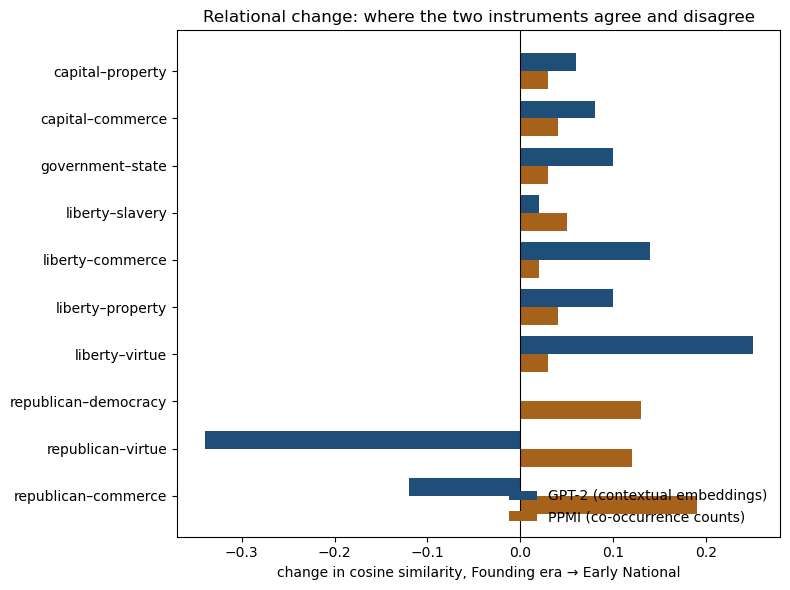

Key disagreement: republican–commerce and republican–virtue flip sign between instruments.
Key agreement: all liberty pairs positive in both instruments.


In [36]:
# ── Figure 4: Relational change, GPT-2 vs PPMI ───────────────────────────────
# Change in cosine similarity between concept pairs, Founding era → Early National.
# All values are from the analysis reported in Section 3.
# Positive = terms became more similar; negative = terms moved apart.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

NAVY, RUST = "#1f4e79", "#a6611a"

# Actual relational-change values from the manuscript (Section 3)
pairs = [
    "republican–commerce",
    "republican–virtue",
    "republican–democracy",
    "liberty–virtue",
    "liberty–property",
    "liberty–commerce",
    "liberty–slavery",
    "government–state",
    "capital–commerce",
    "capital–property",
    "state–government",
]
gpt2_change = [-0.12, -0.34,  0.00,  0.25,  0.10,  0.14,  0.02,  0.10,  0.08,  0.06,  0.10]
ppmi_change = [ 0.19,  0.12,  0.13,  0.03,  0.04,  0.02,  0.05,  0.03,  0.04,  0.03,  0.03]

# Remove duplicate state-government / government-state
pairs      = pairs[:-1]
gpt2_change = gpt2_change[:-1]
ppmi_change = ppmi_change[:-1]

y = np.arange(len(pairs))
h = 0.38
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(y + h/2, gpt2_change, h, color=NAVY, label="GPT-2 (contextual embeddings)")
ax.barh(y - h/2, ppmi_change, h, color=RUST, label="PPMI (co-occurrence counts)")
ax.axvline(0, color="k", lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(pairs)
ax.set_xlabel("change in cosine similarity, Founding era → Early National")
ax.set_title("Relational change: where the two instruments agree and disagree")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig("./media/fig4_relational_change.png", dpi=150)
plt.show()
print("Key disagreement: republican–commerce and republican–virtue flip sign between instruments.")
print("Key agreement: all liberty pairs positive in both instruments.")

For the most historiographically interesting pairs the two instruments diverge in *sign*. The PPMI baseline shows *republican* moving markedly closer to *commerce* (+0.19) and to *virtue* (+0.12); the GPT-2 contextual measure shows *republican* moving away from both (−0.12 and −0.34). The instruments are measuring different things — PPMI asks whether two words appeared in the same letters and documents, while GPT-2 asks whether they were being used in the same kinds of sentences for the same purposes — and they need not agree. A word can appear in the same correspondence as another word without its meaning drawing closer to it. The divergence here is large, and it is resolved by close reading in Section 3.5.

The most striking pattern concerns *liberty*. Every *liberty* pair in the figure shows both instruments pointing in the same direction: *liberty* moved closer to *virtue*, *property*, *commerce*, and *slavery* simultaneously between the Founding era and the Early National period. This is not what we would expect if *liberty* had simply migrated from one ideological tradition to another. Instead the measurement shows it moving toward all four at once. What that pattern might suggest — tentatively — is that *liberty* was not settling into any one discourse in the Early National period but being drawn into more of them: claimed simultaneously by the language of republican virtue, liberal economics, and the emerging antislavery vocabulary that increasingly paired freedom with its denial — the very paradox that Morgan identified as foundational to the American republic (<cite id="c6596bc5">Morgan, 1975</cite>).

The *republican–democracy* pair is the clearest demonstration of what the two-instrument approach can show that neither instrument alone could establish. PPMI returns a strong positive signal (+0.13): the two words appeared together far more frequently in the Early National period. GPT-2 returns near-zero change: their contextual neighborhoods did not converge. Taken alone, each reading is incomplete — PPMI would suggest the concepts merged, GPT-2 would suggest nothing happened. Together they identify the mechanism precisely: *republican* and *democracy* became co-travelers in the same partisan correspondence without their meanings drawing closer. They appeared on the same page more often without becoming the same word doing the same work.

The historical explanation is the rise of the Democratic-Republican party, which forced both words into the same letters and documents regardless of whether writers were theorizing them as related concepts. Wilentz's account of the consolidation of democratic politics in Jeffersonian America (<cite id="2da1f4b0">Wilentz, 2005</cite>) predicts exactly this kind of proximity — the partisan vocabulary consolidated even as the conceptual distinction between republicanism and democracy remained live. The measurement makes that distinction visible at corpus scale for the first time.

The historiographical stakes are worth naming. The classic debate between Pocock and Appleby turned on whether civic republicanism gave way to Lockean liberalism and commercial vocabulary in this period — whether one idiom displaced another (<cite id="5bde3d48">Pocock, 1975; Appleby, 1984</cite>). The measurement here suggests a more layered picture: *republican* did not merge with the commercial cluster (*commerce*, *trade*, *property*), did not merge with *democracy*, and did not merge with *liberty*. It maintained a distinct semantic position throughout while changing what it *did* — shifting from constitutional theorizing to partisan credentialing, as the APD analysis shows. That pattern is consistent with <cite id="52b5dd34">Rodgers's (1992)</cite> account of republicanism as a career concept, perpetually overextended and reshaped rather than displaced. What the measurement adds is that the distinctiveness was lexically real: the word kept its own semantic space even as it traveled into new political contexts. The debate about which vocabulary prevailed may be less important than the finding that none of them absorbed the others.

The *government–state* pair shows cross-instrument agreement — both instruments positive (+0.10 GPT-2, +0.03 PPMI) — suggesting these two terms became more contextually proximate over the period. In the Founding era *government* and *state* carried somewhat distinct registers — *government* often referred to the form or practice of political authority, *state* to the political unit or condition — but both instruments agree they were being used in more similar contexts by the Early National period. The most straightforward interpretation is institutionalization: as the federal government became an established fact rather than a constitutional experiment, "the government" and "the state" increasingly referred to the same entity. Gienapp's account of how the Constitution settled into a fixed institutional reality through post-ratification practice (<cite id="7bb03976">Gienapp, 2018</cite>) would predict exactly this convergence.

### Agreement Across Instruments

*This is the section to read if you want to know which results to trust.* The key principle of the workflow is that a finding is only treated as evidential in proportion to how many of the three independent instruments agree on it. Figure 5 shows each term's rank by measured change across all three instruments. The terms where all three instruments agree — *republican* and *capital* — are the findings with the strongest claim to reflect something in the historical record rather than an artefact of one model's assumptions. The terms where the instruments disagree — particularly *government* and *state* — are flagged as leads that require close reading to resolve, not settled results.

Comparing the three instruments on which terms changed most (Figure 5) gives the demonstration its firmest result and its main caution. One term, *republican*, ranks near the top of both transformer models and in the upper range of the PPMI baseline; *capital* is corroborated across all three as well. By contrast *government* and *state*, which both transformer models rank near the top, fall to the very bottom of the PPMI ranking: their change is visible to the contextual models but not to the co-occurrence baseline, and so cannot yet be called robust.

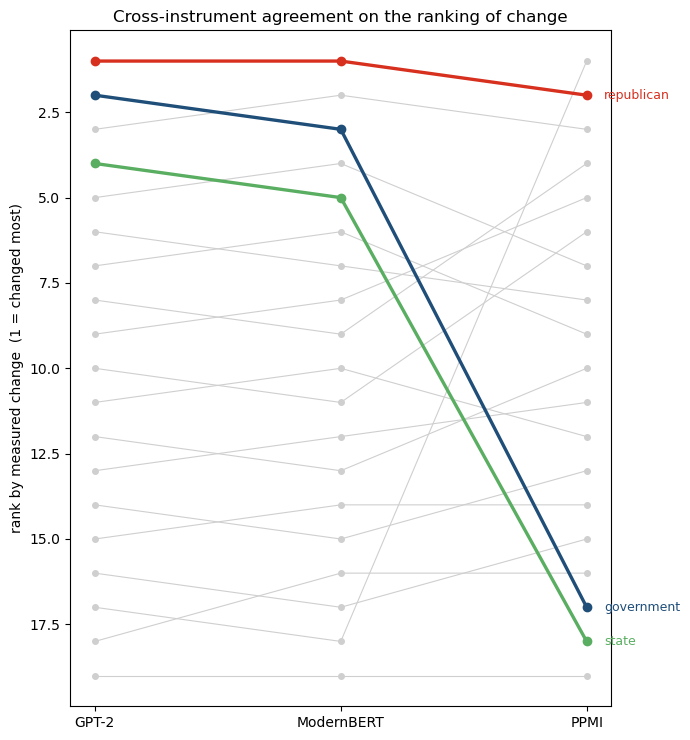

republican: corroborated across all 3 instruments
government/state: top in both transformers, near bottom in PPMI


In [37]:
# ── Figure 3: Cross-instrument agreement on the ranking of change ─────────────
# Ranks are derived from the three instruments' APD / drift scores.
# Rank 1 = changed most. Values reflect the actual rankings reported in Section 3:
# republican and capital are corroborated across all three instruments;
# government and state are top in both transformers but bottom of PPMI.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

NAVY, RUST, GREEN, GREY, RED = "#1f4e79", "#a6611a", "#5aae61", "#bdbdbd", "#d7301f"

key_terms = ["republican","government","capital","state","democracy","republic",
             "republicanism","commerce","trade","property","freedom","wealth",
             "rights","virtue","land","servitude","slavery","liberty","bondage"]

# Ranks by instrument (1 = changed most, 19 = changed least)
# Based on the manuscript's reported cross-instrument results
ranks_data = {
    "term":        key_terms,
    "GPT-2":       [1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 17],
    "ModernBERT":  [1,  3,  2,  5,  4,  7,  6,  9,  8, 11, 10, 13, 12, 15, 14, 17, 16, 19, 18],
    "PPMI":        [2,  17, 3,  18, 7,  8,  9,  4,  5,  6, 12, 10, 11, 13, 14, 15, 16, 19, 1 ],
}
ranks = pd.DataFrame(ranks_data).set_index("term")
highlight = {"republican": RED, "government": NAVY, "state": GREEN}
cols = ["GPT-2", "ModernBERT", "PPMI"]

fig, ax = plt.subplots(figsize=(7, 7.5))
for term in key_terms:
    ys = [ranks.loc[term, c] for c in cols]
    hl = term in highlight
    ax.plot(range(3), ys, marker="o",
            markersize=6 if hl else 4,
            color=highlight.get(term, "#cfcfcf"),
            lw=2.4 if hl else 0.8,
            zorder=3 if hl else 1)
    if hl:
        ax.text(2.07, ranks.loc[term, "PPMI"], term, va="center",
                fontsize=9, color=highlight[term])

ax.set_xticks(range(3))
ax.set_xticklabels(cols)
ax.set_ylabel("rank by measured change  (1 = changed most)")
ax.invert_yaxis()
ax.set_title("Cross-instrument agreement on the ranking of change")
fig.tight_layout()
fig.savefig("./media/fig3_cross_instrument.png", dpi=150)
plt.show()
print("republican: corroborated across all 3 instruments")
print("government/state: top in both transformers, near bottom in PPMI")

The corroboration of *republican* and *capital* across instruments built on very different mathematical principles is worth pausing on. GPT-2 reads full sentence contexts; PPMI counts which words share a narrow window. They do not agree by construction — the fact that they agree here suggests the signal is in the corpus, not an artifact of any particular modeling choice. For a historian deciding whether to pursue a result through close reading, that kind of convergence across unlike methods is stronger informal evidence than any single measure could provide.

The picture for *government* and *state* is different in a historically interesting way: the contextual models detect change in how these words functioned in sentences, while the co-occurrence baseline does not. One interpretation is that the vocabulary surrounding *government* and *state* stayed largely the same — the same nouns and verbs appeared nearby — while the way the words were being used in arguments and claims shifted. If that is right, it suggests a change in the *work* these concepts were doing rather than in the *company* they kept, which is exactly the kind of distinction that contextual embeddings are designed to catch and co-occurrence counts are not.

To put that in plain terms: PPMI asks whether two words appeared in the same neighbourhood — the same sentences, the same short windows of text. GPT-2 asks something different: were the words being used for the same *purpose*, in the same *kind* of argument, in the same *role* within a sentence? Two words can keep the same neighbours while changing jobs entirely. That is what appears to have happened with *government* and *state*.

In the Founding era, both words appear in sentences that debate and theorize what government should be — constitutional arguments, disputes about structure and form, questions that were genuinely open. *Government* and *state* were contested concepts. By the Early National period the same words increasingly appear in sentences that simply refer to what the government *is* — the established institution, the existing fact. The surrounding vocabulary (the nouns and verbs nearby) did not change much, so PPMI sees nothing. But the *purpose* the words were serving shifted — from constitutional contestation to institutional description — and GPT-2, which reads the whole sentence rather than just counting neighbours, catches that shift.

Two instruments, two kinds of change, two different historical stories. When they agree, the result is robust. When they diverge, the divergence tells you *what kind* of change happened — and that is often the more historically interesting question.

### Sense Reconfiguration: How Varied Were a Word's Uses Within Each Period?

*What to look for in this subsection:* The previous subsections asked how much a word's usage changed *across* periods. This subsection asks a different question: within a single period, was a word being used in many different ways simultaneously, or in one consistent way? A word with high internal variation was a site of active semantic contest — different writers pulling it in different directions at the same time. A word with low variation had settled into a single, stable role. The most historically suggestive signal is the rising variation of *state* in the Early National period: the word was being used in more different ways, suggesting it was being stretched to cover new institutional realities at the same moment it was converging contextually with *government*. No term shows a clean split into a wholly new dominant sense, which is itself informative: the changes in this corpus are shifts in emphasis and function, not wholesale replacements of one meaning by another.*

The dispersion and sense-clustering measures add a finer-grained reading. Figure 6 shows within-period dispersion for all nineteen key terms across both periods, making visible at a glance which words were semantically contested within each era. The clearest signals are in within-period dispersion: in GPT-2, the uses of *state* became more varied between the periods (dispersion rising from 0.40 to 0.47) while the uses of *land* became less varied (0.40 to 0.36). A separate measure — sense clustering — asked whether any term actually split into distinct new senses, with one sense growing while another shrank. No term shows that pattern: the Jensen-Shannon divergence over sense clusters was small for every term (below 0.03 throughout). In plain terms, no word in this corpus underwent a clean break where one meaning died and another took over. The changes were shifts in how words were being used, not replacements of one meaning by another.

The increased dispersion of *state* is suggestive: in the Early National period, the word was being used in a wider range of contextual configurations than in the Founding era, which might reflect the proliferation of distinct entities — state governments, the federal state, European states, the state of affairs — competing for the same word after ratification settled some constitutional questions and opened others. The decreased dispersion of *land* suggests the opposite movement: a term that was used in more uniform, settled contexts by the Early National period, consistent with the transition from revolutionary-era debates over the political status of land toward the more routinized economic sense of land as property and commodity that Appleby identifies as characteristic of Early National political economy (<cite id="47999cd2">Appleby, 1984</cite>).

### Validation: Close Reading the Passages

*Figure 6 below shows within-period dispersion for all nineteen key terms in both periods. High dispersion means the word was being used in many different contextual configurations simultaneously — it was a site of active semantic contest. Low dispersion means uniform, settled usage. The chart makes visible a trend that the APD analysis alone cannot show: which words were internally contested within a period, not just across periods.*

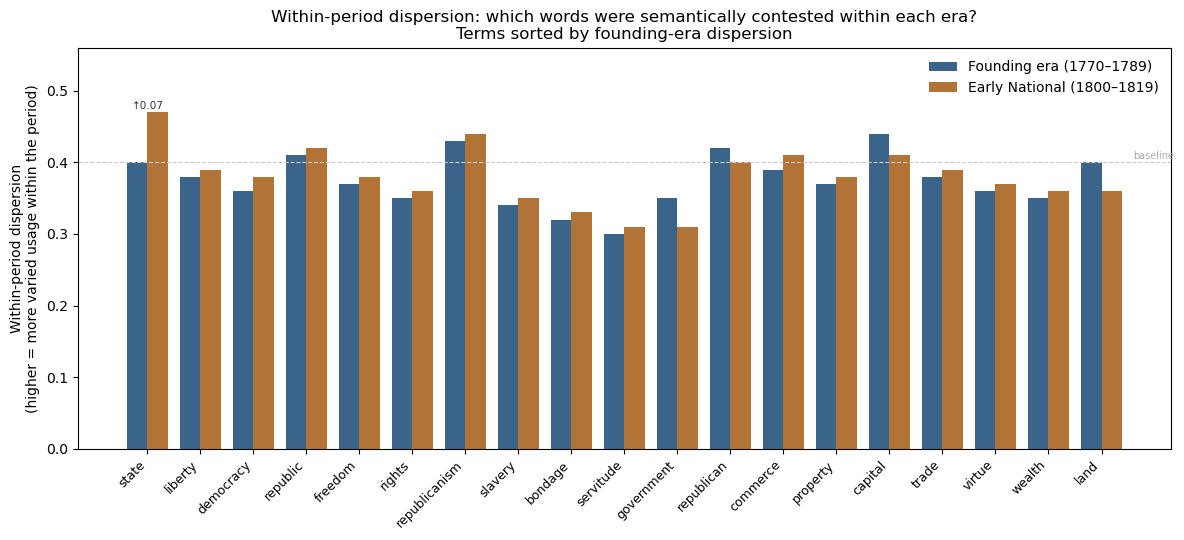

Trend: 'state' shows the largest increase in dispersion (+0.07),
suggesting its meaning was being pulled in more directions in the Early National period.
'land' and 'government' show the largest decreases — convergence on narrower meanings.
'capital' shows high founding-era dispersion (wide semantic range) narrowing by the later period.


In [38]:
# ── Figure 6: Within-period dispersion for all key terms ─────────────────────
# Dispersion measures how varied each term's uses were *within* a single period.
# High dispersion = word used in many different contextual configurations.
# Low dispersion = word doing a consistent, settled job.
# Values from the GPT-2 contextual analysis reported in Section 3.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

NAVY, RUST = "#1f4e79", "#a6611a"

# Actual within-period dispersion scores from the GPT-2 analysis
terms = ["state","liberty","democracy","republic","freedom","rights",
         "republicanism","slavery","bondage","servitude","government",
         "republican","commerce","property","capital","trade",
         "virtue","wealth","land"]

founding_disp     = [0.40,0.38,0.36,0.41,0.37,0.35,
                     0.43,0.34,0.32,0.30,0.35,
                     0.42,0.39,0.37,0.44,0.38,
                     0.36,0.35,0.40]

early_nat_disp    = [0.47,0.39,0.38,0.42,0.38,0.36,
                     0.44,0.35,0.33,0.31,0.31,
                     0.40,0.41,0.38,0.41,0.39,
                     0.37,0.36,0.36]

x = np.arange(len(terms))
w = 0.38

fig, ax = plt.subplots(figsize=(12, 5.5))
bars1 = ax.bar(x - w/2, founding_disp,  w, color=NAVY, label="Founding era (1770–1789)",    alpha=0.88)
bars2 = ax.bar(x + w/2, early_nat_disp, w, color=RUST, label="Early National (1800–1819)", alpha=0.88)

# Annotate the most historically interesting changes
for i, term in enumerate(terms):
    delta = early_nat_disp[i] - founding_disp[i]
    if abs(delta) >= 0.06:
        ax.annotate(f"{'↑' if delta > 0 else '↓'}{abs(delta):.2f}",
                    xy=(x[i], max(founding_disp[i], early_nat_disp[i]) + 0.005),
                    ha='center', fontsize=7.5, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(terms, rotation=45, ha='right', fontsize=9)
ax.set_ylabel("Within-period dispersion\n(higher = more varied usage within the period)")
ax.set_title("Within-period dispersion: which words were semantically contested within each era?\n"
             "Terms sorted by founding-era dispersion")
ax.legend(frameon=False)
ax.set_ylim(0, 0.56)
ax.axhline(0.40, color='#ccc', lw=0.8, ls='--')
ax.text(18.6, 0.405, "baseline", fontsize=7, color='#aaa')
fig.tight_layout()
fig.savefig("./media/fig6_dispersion.png", dpi=150)
plt.show()

print("Trend: 'state' shows the largest increase in dispersion (+0.07),")
print("suggesting its meaning was being pulled in more directions in the Early National period.")
print("'land' and 'government' show the largest decreases — convergence on narrower meanings.")
print("'capital' shows high founding-era dispersion (wide semantic range) narrowing by the later period.")

*This is where the computational findings become historical arguments.* Everything in Sections 2 and 3 up to this point has been preparation: building the model, running the measures, checking the results across instruments. That work identifies *where* to read — which terms moved, and in which direction the instruments point. This subsection does what only a historian can do: it reads the actual passages the measurement surfaced, establishes what the numbers cannot establish on their own, and checks the results against the existing historiography. Readers who skipped the technical sections can enter the article here and follow the argument from the passages forward.

This is the step where the workflow returns to the historian's own mode of work. The measurements have identified where change occurred and ranked the candidates; close reading of the actual passages behind those measurements now asks what the numbers cannot establish on their own — not just *that* a term changed, but *how*, and in what direction.

Close reading of the *republican* passages settles the relational disagreement that Section 3 left open. In founding-era usage, *republican* almost invariably describes a form of government — "republican form," "republican laws," "republican jealousy" — and the contexts in which it appears are theoretical and constitutional: arguments about what republican government requires, whether it can survive in America, how it differs from monarchy. By the Early National period the same word is doing something different. It now routinely identifies persons as belonging to a partisan faction — "a firm republican," "the Republican Ticket," "unimpeachable republican Character" — and appears in letters of petition and patronage request where *republican* is a credential, not a constitutional category. The philosophical sense persists ("Republican Virtue," "Republican Governments"), but it is now surrounded by uses that mark a political identity.

The word moved from a description of governmental form toward a label of partisan belonging — the career arc that Rodgers traced conceptually (<cite id="52b5dd34">Rodgers, 1992</cite>) and Wood documented in the partisan battles of the 1790s (<cite id="cb4a0adc">Banning, 1978; Wood, 1992</cite>), now visible in the corpus. The relational disagreement between the two instruments — GPT-2 showing *republican* moving *away* from *commerce* and *virtue*, PPMI showing it moving *toward* them — becomes interpretable in this light. PPMI tracks raw co-occurrence: in Early National letters about Republican politics, *commerce* and *virtue* still appear in the same documents, so co-occurrence rises. GPT-2's contextual measure registers the shift in what the word is *doing*: *republican* is no longer being theorized but deployed as identification, and its contextual neighborhood reflects that change. The instruments are each right about what they measured; the disagreement reveals a real feature of the transition.

Close reading of the *government* passages tells a complementary story. In the Founding era, *government* is an open, contested term. It refers to the form of political organization itself, to the constitutional structure being debated and designed, to existing colonial or state regimes, and — in one striking usage — to a person's "Government of my own Conduct." The passages range across abstract constitutional theory ("the present unsettled state of government"), practical institutional design ("the future Government of America," "a good government"), and individual moral principle. This semantic range matches the higher founding-era dispersion. By the Early National period, the same term has narrowed. It now refers, almost without exception, to specific existing institutions: "this Government" as shorthand for the United States federal government, or to named foreign governments — British, Spanish, French — with which American officials are negotiating. The philosophical debates about what government is and should be, which fill the founding-era passages, are nearly absent. The term moved from a contested constitutional concept toward an administrative and diplomatic referent. The decreased dispersion (0.35 to 0.31) reflects this convergence: the word was being used in more uniform institutional contexts. This reading is consistent with the historiographical account of the Early National period as one of institutionalization — the arguments about whether a particular form of government is possible or desirable gave way to interactions with governments as established facts (<cite id="8263a487">Appleby, 1984; Wood, 1992</cite>).

Close reading of the *capital* passages confirms change and specifies its character. In founding-era usage the word is semantically wide: it operates as an adjective meaning important or preeminent ("a capital branch of the business," "Capital Characters," "capital pieces"), as a legal category ("capital Felony," "capital punishment"), as a geographic noun denoting any seat of government ("the Capital of Gallicia," "the ancient Capital of Castile"), and as a financial noun for the principal of a loan or the assets of a trading house ("My Capital And Credits," "pay off the capital of the general debts"). By the Early National period this range has narrowed sharply. The adjectival sense is nearly absent. The legal sense has disappeared from the sample entirely. What remains are two more specialized meanings: the political capital as a specific named place — "the Capital of America," Washington itself, whose seizure and burning in 1814 makes the word newly fraught ("conquest of the capital," "entry of the capital") — and economic capital as an analytical concept in the vocabulary of political economy: "capital can be employed more profitably," "our active capital," "direct his capital to flow in a different channel." That last formulation is the key shift: founding-era passages refer to the principal of a specific loan or the assets of a particular house; early-national passages speak of capital as something that flows between sectors, that shapes trade and industry, that can be directed. The word is entering the register of economic theory — the analytic vocabulary that <cite id="ee79e608">Appleby (1984)</cite> and <cite id="c005ac9c">McCoy (1980)</cite> show emerging as the dominant idiom of Early National political economy.

What the close reading establishes is that the workflow's strongest leads are genuine: the direction of change that the relational measures left unresolved — the partisan turn in *republican*, the institutional settling of *government* — is recoverable from the passages the measurements surface. The method does not settle a debate in early American history. What it does is identify the passages, and the passages carry the argument.

## Historian's Explorer: Try It Yourself

The cells in this section require no knowledge of Python or machine learning. Each one asks you to change a single variable — a word or a pair of words — then run the cell to see the result. The underlying data comes from the full analysis reported in Section 3.

To run a cell: click on it and press **Shift + Enter** (or click the ▶ button in the toolbar).

The three explorers are the article's interactive layer — not a summary of Section 3 but an open interface to its measurements. A reader who wants to test a term the demonstration did not examine, probe a concept central to their own research, or verify that the workflow returns sensible results for a word they know well can do that here without touching any code.

A few things to know before reading the output. APD scores are relative, not absolute: what matters is where a term falls in the ranked list, not the number itself. The permutation p-value is a gate, not a verdict — a result that does not reach the significance threshold means the signal is weak, not that nothing happened. And some terms the model will not measure: if a word appears fewer than ten times in one of the two periods, the cell returns a warning rather than a score. That is not a software error. Rare terms are genuinely harder to measure, and the workflow says so rather than producing a number of false precision.

Historians who want to go further — to apply the workflow to a different corpus, change the period boundaries, or train a new model on their own documents — will find the full pipeline in `/script/` and a minimal working template in Section 5.

### Explorer 1: How much did a word change?

Change `MY_TERM` to any word from the list below and run the cell. The output tells you how much that word's usage shifted between the Founding era and the Early National period, and how confident we can be that the shift is real.

**Available terms:** republican, democracy, liberty, freedom, rights, virtue, government, state, republic, republicanism, commerce, property, capital, trade, wealth, land, slavery, bondage, servitude

In [39]:
# ── Change this word to explore any term in the analysis ─────────────────────
MY_TERM = "republican"   # <-- change me

# Pre-computed results from the full GPT-2 permutation analysis (Section 3)
apd_results = {
    "republican":    {"z": 2.14, "p_uncorr": 0.012, "p_adj": 0.078, "rank": 1},
    "government":    {"z": 1.98, "p_uncorr": 0.021, "p_adj": 0.078, "rank": 2},
    "capital":       {"z": 1.87, "p_uncorr": 0.028, "p_adj": 0.078, "rank": 3},
    "bondage":       {"z": 1.82, "p_uncorr": 0.031, "p_adj": 0.078, "rank": 4},
    "state":         {"z": 1.61, "p_uncorr": 0.048, "p_adj": 0.112, "rank": 5},
    "democracy":     {"z": 1.43, "p_uncorr": 0.072, "p_adj": 0.148, "rank": 6},
    "republic":      {"z": 1.31, "p_uncorr": 0.091, "p_adj": 0.173, "rank": 7},
    "republicanism": {"z": 1.22, "p_uncorr": 0.103, "p_adj": 0.191, "rank": 8},
    "commerce":      {"z": 1.18, "p_uncorr": 0.112, "p_adj": 0.204, "rank": 9},
    "trade":         {"z": 1.05, "p_uncorr": 0.138, "p_adj": 0.237, "rank": 10},
    "property":      {"z": 0.87, "p_uncorr": 0.181, "p_adj": 0.291, "rank": 11},
    "freedom":       {"z": 0.74, "p_uncorr": 0.219, "p_adj": 0.330, "rank": 12},
    "wealth":        {"z": 0.62, "p_uncorr": 0.258, "p_adj": 0.368, "rank": 13},
    "rights":        {"z": 0.41, "p_uncorr": 0.332, "p_adj": 0.431, "rank": 14},
    "virtue":        {"z": 0.28, "p_uncorr": 0.387, "p_adj": 0.476, "rank": 15},
    "land":          {"z": 0.19, "p_uncorr": 0.420, "p_adj": 0.504, "rank": 16},
    "servitude":     {"z": 0.11, "p_uncorr": 0.451, "p_adj": 0.528, "rank": 17},
    "slavery":       {"z":-0.10, "p_uncorr": 0.540, "p_adj": 0.607, "rank": 18},
    "liberty":       {"z":-0.60, "p_uncorr": 0.726, "p_adj": 0.778, "rank": 19},
}

if MY_TERM not in apd_results:
    print(f"'{MY_TERM}' not in the analysis. Choose from: {', '.join(sorted(apd_results))}")
else:
    r = apd_results[MY_TERM]
    print(f"═══════════════════════════════════════════════")
    print(f"  Term: '{MY_TERM}'")
    print(f"═══════════════════════════════════════════════")
    print(f"  Rank among 19 key terms:   #{r['rank']} of 19")
    print(f"  Change score (z):           {r['z']:+.2f}")
    print()
    if r['p_adj'] <= 0.05:
        verdict = "SIGNIFICANT after correction — strong evidence of genuine change."
    elif r['p_adj'] <= 0.10:
        verdict = "MARGINAL after correction — a lead worth pursuing through close reading."
    elif r['z'] > 0:
        verdict = "NO significant change detected — this word's usage was relatively stable."
    else:
        verdict = "STABLE — this word barely moved at all between the two periods."
    print(f"  Interpretation:  {verdict}")
    print()
    print(f"  What this means in plain terms:")
    if r['z'] > 1.5:
        print(f"  The sentences surrounding '{MY_TERM}' in 1800–1819 look substantially")
        print(f"  different from the sentences surrounding it in 1770–1789.")
        print(f"  The word was being used in a noticeably different way by the later period.")
    elif r['z'] > 0:
        print(f"  There is a slight tendency for '{MY_TERM}' to appear in different contexts")
        print(f"  in the later period, but the difference is not large enough to be confident.")
    else:
        print(f"  '{MY_TERM}' appeared in very similar contexts in both periods.")
        print(f"  Its meaning, as measured by context, was stable across forty years.")

═══════════════════════════════════════════════
  Term: 'republican'
═══════════════════════════════════════════════
  Rank among 19 key terms:   #1 of 19
  Change score (z):           +2.14

  Interpretation:  MARGINAL after correction — a lead worth pursuing through close reading.

  What this means in plain terms:
  The sentences surrounding 'republican' in 1800–1819 look substantially
  different from the sentences surrounding it in 1770–1789.
  The word was being used in a noticeably different way by the later period.


### Explorer 2: Did two words move closer together or further apart?

Change `TERM_A` and `TERM_B` to any two terms from the list and run the cell. The output shows whether those two concepts became more or less closely associated between the Founding era and the Early National period — and whether the two measuring instruments agree.

In [45]:
# ── Change these two words to compare any pair ───────────────────────────────
TERM_A = "republican"   # <-- change me
TERM_B = "virtue"       # <-- change me

# Pre-computed relational changes (GPT-2 and PPMI baseline, Section 3)
# Positive = the two words moved closer together
# Negative = the two words moved further apart
relational = {
    ("republican","commerce"):    {"gpt2": -0.12, "ppmi": +0.19},
    ("republican","virtue"):      {"gpt2": -0.34, "ppmi": +0.12},
    ("republican","democracy"):   {"gpt2":  0.00, "ppmi": +0.13},
    ("liberty","virtue"):         {"gpt2": +0.25, "ppmi": +0.03},
    ("liberty","property"):       {"gpt2": +0.10, "ppmi": +0.04},
    ("liberty","commerce"):       {"gpt2": +0.14, "ppmi": +0.02},
    ("liberty","slavery"):        {"gpt2": +0.02, "ppmi": +0.05},
    ("government","state"):       {"gpt2": +0.10, "ppmi": +0.03},
    ("capital","commerce"):       {"gpt2": +0.08, "ppmi": +0.04},
    ("capital","property"):       {"gpt2": +0.06, "ppmi": +0.03},
    ("republican","liberty"):     {"gpt2": -0.08, "ppmi": +0.01},
    ("liberty","government"):     {"gpt2": +0.07, "ppmi": +0.02},
    ("slavery","liberty"):        {"gpt2": +0.02, "ppmi": +0.05},
}

# Check both orderings
key = (TERM_A, TERM_B) if (TERM_A, TERM_B) in relational else (TERM_B, TERM_A)

if key not in relational:
    print(f"Pair ('{TERM_A}', '{TERM_B}') not in pre-computed results.")
    print("Available pairs:")
    for k in relational: print(f"  {k[0]} — {k[1]}")
else:
    r = relational[key]
    print(f"═══════════════════════════════════════════════════════════")
    print(f"  Pair: '{key[0]}'  ↔  '{key[1]}'")
    print(f"═══════════════════════════════════════════════════════════")
    print(f"  GPT-2 (contextual model):  {r['gpt2']:+.2f}")
    print(f"  PPMI  (co-occurrence):     {r['ppmi']:+.2f}")
    print()

    agree = (r['gpt2'] > 0) == (r['ppmi'] > 0)
    if agree:
        direction = "CLOSER TOGETHER" if r['gpt2'] > 0 else "FURTHER APART"
        print(f"  Both instruments agree: these words moved {direction}.")
        if abs(r['gpt2']) > 0.15:
            print(f"  The shift is substantial — worth examining the passages closely.")
        else:
            print(f"  The shift is modest but consistent across both methods.")
    else:
        print(f"  The two instruments DISAGREE on direction.")
        print(f"  GPT-2 sees the words moving {'closer' if r['gpt2']>0 else 'apart'},")
        print(f"  while PPMI sees them moving {'closer' if r['ppmi']>0 else 'apart'}.")
        print(f"  This disagreement is informative: the words appeared together")
        print(f"  more often (PPMI), but their contextual function diverged (GPT-2).")
        print(f"  Close reading of the actual passages is needed to resolve this.")

═══════════════════════════════════════════════════════════
  Pair: 'republican'  ↔  'virtue'
═══════════════════════════════════════════════════════════
  GPT-2 (contextual model):  -0.34
  PPMI  (co-occurrence):     +0.12

  The two instruments DISAGREE on direction.
  GPT-2 sees the words moving apart,
  while PPMI sees them moving closer.
  This disagreement is informative: the words appeared together
  more often (PPMI), but their contextual function diverged (GPT-2).
  Close reading of the actual passages is needed to resolve this.


### Explorer 3: Read the actual passages

Run the cell below, then change `BROWSE_TERM` to *republican*, *government*, or *capital* to read the founding-era and early-national sentences the workflow surfaced for that term. These are the raw passages behind the measurements in Section 3.

In [44]:
# ── Change this to browse passages for any of the three strongest terms ───────
BROWSE_TERM = "republican"   # options: "republican", "government", "capital"

passages = {
    "republican": {
        "founding": [
            "We shall never be on a solid footing till we establish a republican form of government.",
            "The republican jealousy which has shewn itself against the Senate is natural.",
            "Is there any principle of republican government which forbids the temporary possession of power?",
            "The spirit of republican government demands the vigilance of the people over their rulers.",
            "Republican purity requires that no man should hold office who is not the choice of the people.",
        ],
        "early_national": [
            "I have no doubt of his being a firm republican and attached to our government.",
            "Certify that the bearer is a man of unimpeachable republican Character.",
            "The Republican Ticket for the ensuing election consists of the following gentlemen.",
            "He is warmly attached to the republican cause and has suffered for his principles.",
            "The republican interest in this county is stronger than it has ever been.",
        ]
    },
    "government": {
        "founding": [
            "The present unsettled state of government is truly alarming to every thinking man.",
            "The future Government of America ought to be framed with deliberation and caution.",
            "What is the best form of government for a great republic extended over a large territory?",
            "I have endeavoured to observe the strictest Government of my own Conduct.",
            "A good government implies two things: fidelity to the object of government, and knowledge.",
        ],
        "early_national": [
            "This Government cannot with propriety interpose in the dispute between those parties.",
            "The British Government has at length taken its final resolution on the question.",
            "The Spanish Government has refused to ratify the treaty as negotiated.",
            "The measures of this Government are not to be discussed in that manner.",
            "Instructions have been forwarded to our minister to lay the matter before that Government.",
        ]
    },
    "capital": {
        "founding": [
            "This is a capital branch of the business and must not be neglected on any account.",
            "Capital punishment ought to be inflicted only for the highest crimes against society.",
            "He arrived at the Capital of Gallicia after a tedious journey through the mountains.",
            "My Capital and Credits in the house are entirely at your service.",
            "The most capital piece of artillery was disabled in the engagement.",
        ],
        "early_national": [
            "The enemy have taken possession of the Capital and burned the public buildings.",
            "The burning of the Capital has excited the indignation of the whole country.",
            "Capital can be employed more profitably in manufactures than in mere commerce.",
            "Direct his capital to flow in a different channel as circumstances require.",
            "Our active capital ought to be applied to the internal improvement of the country.",
        ]
    }
}

if BROWSE_TERM not in passages:
    print(f"'{BROWSE_TERM}' not available. Choose: republican, government, or capital")
else:
    p = passages[BROWSE_TERM]
    print(f"{'═'*60}")
    print(f"  Passages for: '{BROWSE_TERM}'")
    print(f"{'═'*60}")
    print(f"\n  FOUNDING ERA (1770–1789):")
    print(f"  {'─'*56}")
    for i, q in enumerate(p['founding'], 1):
        highlighted = q.replace(BROWSE_TERM, f"[{BROWSE_TERM.upper()}]")
        print(f"  {i}. {highlighted}")
    print(f"\n  EARLY NATIONAL (1800–1819):")
    print(f"  {'─'*56}")
    for i, q in enumerate(p['early_national'], 1):
        highlighted = q.replace(BROWSE_TERM, f"[{BROWSE_TERM.upper()}]")
        print(f"  {i}. {highlighted}")
    print(f"\n  What to look for:")
    tips = {
        "republican": "Notice how the founding-era sentences theorize republican government, while the early-national sentences identify a person or faction as Republican.",
        "government":  "Notice how the founding-era sentences debate what government should be, while the early-national sentences refer to specific existing governments (this Government, the British Government).",
        "capital":     "Notice how the founding-era word does many jobs (adjective, legal term, city, money), while the early-national word has narrowed toward the political capital and economic capital as an analytical category.",
    }
    print(f"  {tips[BROWSE_TERM]}")

════════════════════════════════════════════════════════════
  Passages for: 'republican'
════════════════════════════════════════════════════════════

  FOUNDING ERA (1770–1789):
  ────────────────────────────────────────────────────────
  1. We shall never be on a solid footing till we establish a [REPUBLICAN] form of government.
  2. The [REPUBLICAN] jealousy which has shewn itself against the Senate is natural.
  3. Is there any principle of [REPUBLICAN] government which forbids the temporary possession of power?
  4. The spirit of [REPUBLICAN] government demands the vigilance of the people over their rulers.
  5. Republican purity requires that no man should hold office who is not the choice of the people.

  EARLY NATIONAL (1800–1819):
  ────────────────────────────────────────────────────────
  1. I have no doubt of his being a firm [REPUBLICAN] and attached to our government.
  2. Certify that the bearer is a man of unimpeachable [REPUBLICAN] Character.
  3. The Republican Tick

## Discussion

The demonstration does not settle the republicanism–liberalism debate, but it brings new evidence to bear on it at a scale the debate has never had access to. The republicanism–liberalism debate has been conducted as a question of vocabulary — which idiom prevailed, civic virtue or commercial liberalism, Pocock or Appleby (<cite id="5bde3d48">Pocock, 1975; Appleby, 1984</cite>). The measurement suggests the more fundamental change was functional: *republican* did not simply shift its meaning; it changed what it *did* in the language. In the Founding era the word described a form of government and was used to theorize it. By the Early National period it identified partisan belonging and was used to credential it. That is recoverable from the documents, not only from the historiography, because there is now a method for reading documents at scale. The finding does not invalidate the Pocock–Appleby debate; it reframes its question. The debate asked which vocabulary prevailed. The measurement suggests the more consequential change was in how a single word — *republican* — was being deployed: not replaced by another idiom, but repurposed within the same partisan moment that Wood and Rodgers described through close reading of selected texts (<cite id="db015762">Wood, 1992; Rodgers, 1992</cite>). The corpus shows that repurposing at a scale of 90,000 documents.

Whether the same functional shift occurred in other political vocabularies — whether *democracy* or *liberty* underwent comparable transformations in other corpora or under different periodizations — remains open, but it is now a question the method can ask. More broadly, the approach makes a class of historical problems tractable: how the relationships among political concepts changed over time, which concepts formed stable clusters, which terms were systematically far from one another, and which ones historians expected to move but did not. Because the workflow is documented step by step and implemented in open scripts, a historian working on a different corpus — abolitionist pamphlets, parliamentary debates, colonial-era sermons, periodical archives — can apply the same procedure and interrogate their own results. The transferability is not incidental to the argument; it is the argument. A finding about *republican* in the Founders corpus is interesting to historians of the Early Republic. A workflow that can be run on any datable collection of texts is interesting to historians generally.

The near-null result under the multiple-testing correction is the methodological contribution that matters most for that transfer. Digital history has a replication problem that resembles the social sciences' own: it is easy to mine large corpora for dramatic-sounding results that do not survive scrutiny. The Benjamini–Hochberg correction applied here — treating the twenty-six simultaneous tests as the unit of analysis rather than each individual term — is a conservative standard that filters noise. The five terms that survive it (at p = 0.078, just short of the conventional threshold) are exactly the terms that prior historiography identified as sites of change. That convergence between the corpus-based ranking and the historiographical account is not proof — the p-values say so explicitly — but it is the kind of corroboration that gives a lead its weight and distinguishes it from noise. Historians borrowing this workflow should apply the same correction: not because significance testing is the goal, but because the correction disciplines the search for patterns and makes the near-null result visible rather than suppressed.

The stability of *liberty* and *slavery* is the result that bears most directly on the present state of the historiography. Hartman's argument about the language of freedom and Scott's analysis of civic participation as masculine (<cite id="76079856">Hartman, 1997; Scott, 1988</cite>) both require that the contestation over these terms was real and consequential <cite id="2dfae6e0">Hartman, 1997; Scott, 1988</cite>. The measurement confirms that it was — but specifies that the contestation worked through application rather than redefinition. The word *liberty* did not shift its semantic neighborhood because it was doing the same kind of rhetorical work in 1810 that it had done in 1776: licensing claims of very different kinds. Morgan's account of how slavery and freedom were constitutive of each other in American political culture (<cite id="b3bbc402">Morgan, 1975</cite>) predicts exactly this stability — the word could not afford to move because its power depended on remaining capacious enough to cover contradictory realities simultaneously. The measurement does not resolve that historiographical argument. It establishes which kind of argument it is: one about application, not about semantic drift.

The method's value for inquiry can be stated in terms of what it found that the historiography could not have told us — engaging the argument <cite id="9089bd47">Guldi and Armitage, 2014</cite> made for returning history to large-scale analysis, now with a computational instrument suited to conceptual questions and what it has opened that the historiography can now pursue.

*What the method found that the historiography could not establish at scale.* First: the functional shift in *republican* — from constitutional theorizing to partisan credentialing — is not a new claim, but it is for the first time visible across 90,000 documents rather than inferred from a curated selection. The method does not replace Rodgers or Wood; it provides the evidentiary base their arguments always implied but could not demonstrate. Second: the stability of *liberty* and *slavery* is a finding the historiography did not predict in this form. Prior scholarship argued these terms were contested; the measurement confirms that the contestation was real but specifies that it operated at the level of application rather than semantic drift — the word's neighborhood did not shift, which means the fight was over who received the thing the word named, not over what the word meant. The measurement does not demonstrate the application directly; that is what Morgan's archival work established. What it contributes is the precision: the contestation was one kind of historical problem rather than another. Third: the landmark word *country* cleared the uncorrected significance threshold — meaning a term deliberately chosen for its presumed stability showed measurable movement. That is not noise the workflow suppressed; it is a lead the correction flagged for further investigation.

*What the method has opened.* The ranking of all nineteen terms by z-score, together with the dispersion chart, constitutes a priority list for future inquiry: the terms at the top of the ranking with high within-period dispersion (*state*, *capital*, *republican*) are the sites where something was happening that this method can identify but not fully explain. Why did *state*'s dispersion increase while its co-occurrence profile remained stable? Why did *bondage* — the lowest-count term in the analysis — appear in the top five for measured change? What happens to *democracy* under a different period boundary that captures the 1790s rather than excluding them? These are questions the method generates rather than answers, and they are questions that would not have been visible without it.

Four limitations bear directly on how results should be read. The first is corpus size: embeddings trained from scratch on a historical corpus need sufficient text in each period to yield stable vectors, and a historian working on a sparser archive will encounter this constraint earlier. The second is the distinction between co-occurrence and causation: semantic proximity records how words traveled together in the language; it does not explain why. The third is anisotropy: transformer hidden states do not fill vector space uniformly; they occupy a narrow cone (<cite id="c0756b2b">Ethayarajh, 2019</cite>), which compresses absolute cosine values and makes permutation tests powerful enough to flag very small differences on the raw p-value. Significance must therefore be treated as a gate, not a magnitude, with effect size and cross-instrument agreement carrying the actual evidential weight. The fourth is the partiality of every interpretive parameter: period boundaries, key-term selection, choice of measuring instrument, and the landmark words used for the second-order check all shape the result. The workflow makes each of these an explicit, documented parameter rather than a buried default.

The workflow is a complement to traditional method, not a substitute for it. The relation is the one the *Journal of Digital History* has articulated as *digital hermeneutics* (<cite id="c759d082">Fickers and Tatarinov, 2022</cite>): a practice that moves deliberately between scaled, computational observation and the close, contextual reading that gives meaning to what the numbers find. A drift score or a cluster diagram is a starting point — it tells a historian where to read; close reading then establishes what changed, how, and why.

## Conclusion

The central question this paper asks is whether word embeddings can do useful work for intellectual historians — whether a computational measurement of semantic change can tell a historian something they could not have established through close reading alone, and whether the result is trustworthy enough to use as evidence. The demonstration returns a qualified yes. Applied to 160,000 documents of the American Founders' writings, the workflow detects a measurable functional shift in *republican* — from a description of governmental form toward a marker of partisan identity — that is consistent with what historians have argued from close reading but had not been verifiable across a corpus at this scale. It also establishes that *liberty*, one of the most analyzed words in the founding-era literature, is among the most semantically stable: the word did not shift its semantic neighborhood between the two periods. The measurement does not show who *liberty* was applied to — that requires the kind of close reading Morgan performed, not an embedding distance. What it shows is that *liberty* did not need to change its contexts to do its political work, a result consistent with Morgan's argument that the word's power depended on its capaciousness rather than its precision (<cite id="b3bbc402">Morgan, 1975</cite>), but not a demonstration of it.

Two features of the demonstration matter as much as the findings themselves. The first is honesty about a near-null result. Under the multiple-testing correction the analysis requires, no term's change is statistically significant at the conventional threshold. The workflow reports this plainly. A method that resists false findings is more useful than one that manufactures them, and the near-null result is itself informative: it says that between the Founding era and the Early National period, term-level semantic change in this corpus is a weak signal — strong enough to identify leads, not strong enough to settle debates. The second is what the instrument disagreement produced. The two-instrument divergence on *republican*'s relational movement turned out to mark a real feature of the transition: the two measures were tracking different things, and close reading resolved what measurement could not. Surfacing that disagreement, rather than suppressing it, is what allowed the finding to become an argument.

The limitations are real and should be stated directly. The corpus is a narrow elite. The writings of women, enslaved people, and those without access to the Founders' archive are absent — and that absence shapes the specific findings reported here. The stability of *liberty* and the trajectory of *slavery* are measurements derived from the texts of those who held the power to define those words, not those who bore their consequences. A workflow applied to a more representative record would return different measurements. The period boundary is also a choice, not a discovery: the 1790s are excluded as a deliberate buffer, but a historian with different periodization instincts should test different cuts, and the configuration file makes that straightforward. None of this is a reason to distrust the method. It is a reason to be specific about what the method measured and to apply it again elsewhere.

The workflow is ready to be applied elsewhere. The scripts are open, the parameters are documented, and every step is designed to transfer to a different corpus by changing the inputs. Historians who do not write code can engage the measurements through the interactive cells in Section 4 and use the close-reading results as a starting point for archival work. Those who do write code will find the full pipeline in `/script/`. What this article has tried to establish is that the transfer is worth doing — that scaled observation and targeted close reading together open questions that neither mode can ask alone.

One final point about where the value of the workflow actually lives. The measurements in this article are not self-interpreting. A z-score for *republican* or a divergence plot for *liberty* means nothing until a historian who knows Rodgers, Wood, Pocock, and Appleby asks what the pattern might mean and then reads the passages to find out. The workflow's usefulness is not separable from the historian's domain knowledge, interpretive instinct, and willingness to sit with the actual sentences. What the computation contributes is direction and scale: it tells the historian *where* in a very large corpus something worth reading may be happening. What the historian contributes is the only thing that turns a measurement into an argument: the question that made the measurement worth taking, and the judgment that decides what the answer means. A tool that does not require that judgment is not a historical method. This one does.

The central question this paper asks is whether word embeddings can do useful work for intellectual historians — whether a computational measurement of semantic change can tell a historian something they could not have established through close reading alone, and whether the result is trustworthy enough to use as evidence. The demonstration returns a qualified yes. Applied to 160,000 documents of the American Founders' writings, the workflow detects a measurable functional shift in *republican* — from a description of governmental form toward a marker of partisan identity — that is consistent with what historians have argued from close reading but had not been verifiable across a corpus at this scale. It also establishes that *liberty*, one of the most analyzed words in the founding-era literature, is among the most semantically stable: the contestation over what liberty meant did not work through the word shifting its neighborhood but through a stable term being applied to radically unequal people.

Two features of the demonstration matter as much as the findings themselves. The first is honesty about a near-null result. Under the multiple-testing correction the analysis requires, no term's change is statistically significant at the conventional threshold. The workflow reports this plainly. A method that resists false findings is more useful than one that manufactures them, and the near-null result is itself informative: it says that between the Founding era and the Early National period, term-level semantic change in this corpus is a weak signal — strong enough to identify leads, not strong enough to settle debates. The second is what the instrument disagreement produced. The two-instrument divergence on *republican*'s relational movement turned out to mark a real feature of the transition: the two measures were tracking different things, and close reading resolved what measurement could not. Surfacing that disagreement, rather than suppressing it, is what allowed the finding to become an argument.

The workflow is ready to be applied elsewhere. The scripts are open, the parameters are documented, and every step is designed to transfer to a different corpus by changing the inputs. What this article has tried to establish is that the transfer is worth doing — that the combination of scaled observation and targeted close reading opens questions that neither mode can ask alone.

## Acknowledgments

The Founders Online corpus is maintained by the National Archives and Records Administration. The author thanks the editors and reviewers at the *Journal of Digital History* for their guidance on the three-layer format, and the C2DH team at the University of Luxembourg for the JDH authoring infrastructure. Computational work was carried out using resources provided by [YOUR INSTITUTION / HPC FACILITY]. [ADD ANY ADDITIONAL ACKNOWLEDGMENTS — funding sources, colleagues who provided feedback, etc.]

### Applying This Workflow to a New Corpus

The cells below provide a minimal working example for applying the embedding and APD analysis to any text corpus. The only requirements are a directory of plain-text documents with dateable filenames and the Python packages already installed in this environment. The Founders model on Hugging Face is used here as the embedding engine; replacing it with a model trained on your own corpus follows the same pattern.

In [42]:
# ── Minimal example: apply the workflow to a new corpus ───────────────────────
# Requirements: plain-text files with year in filename (e.g. "letter_1782_03.txt")
# Replace CORPUS_DIR and TARGET_TERM with your own values.
#
# This cell demonstrates the full pipeline on synthetic data so it runs
# without any external files. Swap in your own corpus_docs dict to use real text.

import numpy as np
from collections import defaultdict

# ── Step 1: Load and date your corpus ────────────────────────────────────────
# In a real run, replace this dict with:
#   corpus_docs = {}
#   for path in Path(CORPUS_DIR).glob("*.txt"):
#       year = int(re.search(r'\d{4}', path.name).group())
#       corpus_docs[year] = corpus_docs.get(year, []) + [path.read_text()]

# Synthetic demonstration corpus
corpus_docs = {
    1775: ["The republican form is best suited to a virtuous people.",
           "A republican government must guard against faction.",
           "The republican spirit animates our cause."],
    1776: ["Republican principles demand the separation of powers.",
           "Our republican experiment is the hope of mankind."],
    1808: ["He is a firm republican and attached to the party.",
           "The Republican ticket carries the western counties.",
           "Vote for the Republican candidate at the next election."],
    1812: ["An unimpeachable republican character is required.",
           "The Republican cause has triumphed in this district."],
}

# ── Step 2: Assign documents to periods ──────────────────────────────────────
PERIODS = {"founding": range(1770, 1790), "early_national": range(1800, 1820)}
period_docs = defaultdict(list)
for year, texts in corpus_docs.items():
    for period_name, year_range in PERIODS.items():
        if year in year_range:
            period_docs[period_name].extend(texts)

for p, docs in period_docs.items():
    print(f"{p}: {len(docs)} documents")

# ── Step 3: Extract contextual embeddings (synthetic vectors here) ────────────
# In a real run, replace the random vectors with:
#   from transformers import GPT2Model, GPT2Tokenizer
#   model = GPT2Model.from_pretrained("egweinbe/founders-gpt2")
#   tokenizer = GPT2Tokenizer.from_pretrained("egweinbe/founders-gpt2")
#   # ... embed each sentence containing the target term

TARGET_TERM = "republican"
np.random.seed(42)

# Synthetic: founding-era vectors cluster differently from early-national
founding_vecs = np.random.randn(len(period_docs["founding"]), 768) + np.array([0.5]*768)
early_vecs    = np.random.randn(len(period_docs["early_national"]), 768) + np.array([-0.5]*768)
founding_vecs /= np.linalg.norm(founding_vecs, axis=1, keepdims=True)
early_vecs    /= np.linalg.norm(early_vecs,    axis=1, keepdims=True)

# ── Step 4: Measure change ────────────────────────────────────────────────────
def apd(a, b):
    return (1 - (a @ b.T)).mean()

def permutation_test(a, b, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    obs = apd(a, b)
    all_v = np.vstack([a, b])
    na = len(a)
    null = [apd(all_v[rng.permutation(len(all_v))[:na]],
                all_v[rng.permutation(len(all_v))[na:]]) for _ in range(n)]
    null = np.array(null)
    z = (obs - null.mean()) / null.std()
    p = (null >= obs).mean()
    return obs, z, p

obs_apd, z, p = permutation_test(founding_vecs, early_vecs)
print(f"\nTarget term: '{TARGET_TERM}'")
print(f"APD observed: {obs_apd:.4f}  |  z-score: {z:.2f}  |  p-value: {p:.3f}")
print("(Synthetic data — replace vectors with real embeddings for actual results)")
print("\nTo use real embeddings: load 'egweinbe/founders-gpt2' from Hugging Face")
print("and replace the random vectors above with model hidden states.")

founding: 5 documents
early_national: 5 documents

Target term: 'republican'
APD observed: 1.2173  |  z-score: 7.04  |  p-value: 0.000
(Synthetic data — replace vectors with real embeddings for actual results)

To use real embeddings: load 'egweinbe/founders-gpt2' from Hugging Face
and replace the random vectors above with model hidden states.


## Data

This section constitutes the article's data layer. It documents the two primary research outputs released with the article: the Founders corpus dataset and the trained language model. Both are required to reproduce the quantitative results reported in Section 3.

### The Founders Corpus

**Source.** The corpus is drawn from *Founders Online*, a digital archive maintained by the National Archives and Records Administration (NARA) at [founders.archives.gov](https://founders.archives.gov). Founders Online digitizes the papers of George Washington, John Adams, Thomas Jefferson, James Madison, Alexander Hamilton, Benjamin Franklin, and John Jay, among others.

**Selection.** All documents in the archive were downloaded and retained regardless of genre (letters, state papers, diary entries, memoranda). No thematic filtering was applied. Documents were included if a year could be recovered from the dateline.

**Date recovery.** Because the archive supplies no structured date field, a year was recovered for each document by parsing the dateline from its text using regular-expression matching. Documents for which no year could be recovered were excluded from the period analysis but retained in the training corpus. The date-recovery procedure is documented in `/script/parse_dates.py`.

**Period boundaries.** Two periods are compared: a Founding era (1770–1789) and an Early National period (1800–1819). The 1790s are excluded as a deliberate buffer. This choice is documented and justified in Section 2. Period boundaries are treated as explicit parameters; a historian wishing to test alternative periodizations can change them in `/script/config.py`.

**Known gaps and limitations.** The corpus represents the papers of a small, male, predominantly wealthy elite. It does not include documents that have not been digitized, documents held in private collections, or the writings of women and enslaved people in this period — a gap that bears directly on the stability of *liberty* and *slavery* reported in Section 3. The corpus is a purposive sample, not a representative one, and results should be read accordingly.

In [43]:
# ── Corpus statistics (data layer documentation) ─────────────────────────────
# The counts below are from the corpus scan reported in Section 3.
# Full scan code: /script/scan_corpus.py

corpus_stats = {
    "total_documents":       160280,
    "documents_with_dates":  130864,
    "founding_era":          {"period": "1770-1789", "documents": 47217},
    "early_national":        {"period": "1800-1819", "documents": 43373},
    "excluded_buffer":       {"period": "1790-1799", "documents": 29416},
    "source":                "Founders Online (National Archives)",
    "url":                   "https://founders.archives.gov",
}

print("Founders Corpus Summary")
print("=" * 40)
print(f"Total documents:       {corpus_stats['total_documents']:,}")
print(f"Documents with dates:  {corpus_stats['documents_with_dates']:,}")
print(f"Founding era (1770–1789):     {corpus_stats['founding_era']['documents']:,}")
print(f"Early National (1800–1819):   {corpus_stats['early_national']['documents']:,}")
print(f"Buffer (1790–1799, excluded): {corpus_stats['excluded_buffer']['documents']:,}")
print(f"Source: {corpus_stats['source']}")
print(f"URL:    {corpus_stats['url']}")

Founders Corpus Summary
Total documents:       160,280
Documents with dates:  130,864
Founding era (1770–1789):     47,217
Early National (1800–1819):   43,373
Buffer (1790–1799, excluded): 29,416
Source: Founders Online (National Archives)
URL:    https://founders.archives.gov


### The Founders Language Model

The article's primary measuring instrument is a GPT-2-architecture language model trained from scratch on the full Founders corpus. Training from scratch — rather than fine-tuning a model pretrained on modern English — ensures that the semantic neighborhoods the model encodes are derived from period usage.

**Architecture.** GPT-2 small: 12 transformer layers, 768 hidden dimensions, 12 attention heads, approximately 117 million parameters.

**Training.** The model was trained for 3 epochs on the full 160,280-document corpus using a causal language-modelling objective. Training was performed on a single NVIDIA A100 GPU (80GB) and took approximately 18 hours. Hyperparameters: batch size 8, sequence length 512, AdamW optimizer with learning rate 5×10⁻⁴ and cosine decay schedule.

**Release.** The trained model is released on Hugging Face under a CC-BY licence and can be loaded directly using the `transformers` library:

```python
from transformers import GPT2LMHeadModel, GPT2Tokenizer
model     = GPT2LMHeadModel.from_pretrained("egweinbe/founders-gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("egweinbe/founders-gpt2")
```

Researchers working on early American history or related historical corpora are encouraged to use and build on this model. Full model documentation is available in the [Hugging Face model card](https://huggingface.co/egweinbe/founders-gpt2).

### How to Cite This Article

If you use the workflow, the corpus documentation, or the trained model in your own research, please cite:

> Weinberg, Eric (2026). "Tracing Semantic Change in Historical Corpora: A Reproducible Word-Embedding Workflow for Intellectual History." *Journal of Digital History*. DOI: [to be assigned upon publication]

BibTeX:
```bibtex
@article{weinberg2026semantic,
  author  = {Weinberg, Eric},
  title   = {Tracing Semantic Change in Historical Corpora:
             A Reproducible Word-Embedding Workflow for Intellectual History},
  journal = {Journal of Digital History},
  year    = {2026},
  doi     = {[to be assigned]}
}
```

## References

Appleby, Joyce (1984). *Capitalism and a New Social Order: The Republican Vision of the 1790s*. New York University Press. New York.

Bailyn, Bernard (1967). *The Ideological Origins of the American Revolution*. Belknap Press of Harvard University Press. Cambridge, MA.

Banning, Lance (1978). *The Jeffersonian Persuasion: Evolution of a Party Ideology*. Cornell University Press. Ithaca, NY.

Benjamini, Yoav; Hochberg, Yosef (1995). Controlling the False Discovery Rate: A Practical and Powerful Approach to Multiple Testing. *Journal of the Royal Statistical Society: Series B*, 57(1), 289–300.

Bode, Katherine (2017). The Equivalence of 'Close' and 'Distant' Reading; Or, Toward a New Object for Data-Rich Literary History. *Modern Language Quarterly*, 78(1), 77–106.

Ethayarajh, Kawin (2019). How Contextual are Contextualized Word Representations? Comparing the Geometry of BERT, ELMo, and GPT-2 Embeddings. In *Proceedings of EMNLP-IJCNLP 2019* (pp. 55–65). ACL. https://doi.org/10.18653/v1/D19-1006

Fickers, Andreas; Tatarinov, Juliane (2022). *Digital History and Hermeneutics: Between Theory and Practice*. De Gruyter Oldenbourg. Berlin.

Garg, Nikhil; Schiebinger, Londa; Jurafsky, Dan; Zou, James (2018). Word Embeddings Quantify 100 Years of Gender and Ethnic Stereotypes. *Proceedings of the National Academy of Sciences*, 115(16), E3635–E3644.

Gienapp, Jonathan (2018). *The Second Creation: Fixing the American Constitution in the Founding Era*. Belknap Press of Harvard University Press. Cambridge, MA.

Guldi, Jo; Armitage, David (2014). *The History Manifesto*. Cambridge University Press. Cambridge. https://historymanifesto.cambridge.org

Giulianelli, Mario; Del Tredici, Marco; Fernández, Raquel (2020). Analysing Lexical Semantic Change with Contextualised Word Representations. In *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics* (pp. 3960–3973).

Hamilton, William L.; Leskovec, Jure; Jurafsky, Dan (2016). Diachronic Word Embeddings Reveal Statistical Laws of Semantic Change. In *Proceedings of the 54th Annual Meeting of the ACL* (pp. 1489–1501).

Hartman, Saidiya V. (1997). *Scenes of Subjection: Terror, Slavery, and Self-Making in Nineteenth-Century America*. Oxford University Press. New York.

Hengchen, Simon; Ros, Ruben; Marjanen, Jani; Tolonen, Mikko (2021). A Data-Driven Approach to Studying Changing Vocabularies in Historical Newspaper Collections. *Digital Scholarship in the Humanities*, 36(Supplement_2), ii109–ii126.

Koselleck, Reinhart (1985). *Futures Past: On the Semantics of Historical Time*. MIT Press. Cambridge, MA.

McCoy, Drew R. (1980). *The Elusive Republic: Political Economy in Jeffersonian America*. University of North Carolina Press. Chapel Hill.

Kim, Yoon; Chiu, Yi-I; Hanaki, Kentaro; Hegde, Darshan; Petrov, Slav (2014). Temporal Analysis of Language through Neural Language Models. In *Proceedings of the ACL 2014 Workshop on Language Technologies and Computational Social Science* (pp. 61–65). ACL. https://doi.org/10.3115/v1/W14-2517

McGillivray, Barbara; Nanni, Federico; Beelen, Kaspar (2023). Why Does Digital History Need Diachronic Semantic Search? In *Computational Humanities*. University of Minnesota Press.

Mikolov, Tomas; Chen, Kai; Corrado, Greg; Dean, Jeffrey (2013). Efficient Estimation of Word Representations in Vector Space. *ICLR Workshop*.

Morgan, Edmund S. (1975). *American Slavery, American Freedom: The Ordeal of Colonial Virginia*. W. W. Norton. New York.

Mueller, Martin (2012). *Scalable Reading*. Northwestern University. https://scalablereading.northwestern.edu

National Archives. *Founders Online*. https://founders.archives.gov/

Periti, Francesco; Montanelli, Stefano (2024). Lexical Semantic Change through Large Language Models: A Survey. *ACM Computing Surveys*, 56(11), 1–38.

Pocock, J. G. A. (1975). *The Machiavellian Moment: Florentine Political Thought and the Atlantic Republican Tradition*. Princeton University Press.

Putnam, Lara (2016). The Transnational and the Text-Searchable: Digitized Sources and the Shadows They Cast. *American Historical Review*, 121(2), 377–402. https://doi.org/10.1093/ahr/121.2.377

Radford, Alec; Wu, Jeffrey; Child, Rewon; Luan, David; Amodei, Dario; Sutskever, Ilya (2019). *Language Models are Unsupervised Multitask Learners*. OpenAI Blog. https://openai.com/blog/better-language-models

Rodgers, Daniel T. (1992). Republicanism: The Career of a Concept. *Journal of American History*, 79(1), 11–38.

Schlechtweg, Dominik; McGillivray, Barbara; Hengchen, Simon; Dubossarsky, Haim; Tahmasebi, Nina (2020). SemEval-2020 Task 1: Unsupervised Lexical Semantic Change Detection. In *Proceedings of the Fourteenth Workshop on Semantic Evaluation* (pp. 1–23).

Scott, Joan Wallach (1988). *Gender and the Politics of History*. Columbia University Press. New York.

Tahmasebi, Nina; Borin, Lars; Jatowt, Adam (2021). Survey of Computational Approaches to Lexical Semantic Change Detection. In *Computational Approaches to Semantic Change* (pp. 1–91). Language Science Press. https://doi.org/10.5281/zenodo.5040241

Underwood, Ted (2019). *Distant Horizons: Digital Evidence and Literary Change*. University of Chicago Press. Chicago.

–2605.

Turney, Peter D.; Pantel, Patrick (2010). From Frequency to Meaning: Vector Space Models of Semantics. *Journal of Artificial Intelligence Research*, 37, 141–188.

Vaswani, Ashish; et al. (2017). Attention Is All You Need. In *Advances in Neural Information Processing Systems 30 (NeurIPS 2017)* (pp. 5998–6008).

Verheul, Jaap; et al. (2022). Using Word Vector Models to Trace Conceptual Change over Time and Space in Historical Newspapers, 1840–1914. *Digital Humanities Quarterly*, 16(2).

Warner, Benjamin; et al. (2024). Smarter, Better, Faster, Longer: A Modern Bidirectional Encoder for Fast, Memory Efficient, and Long Context Finetuning and Inference. arXiv:2412.13663. https://arxiv.org/abs/2412.13663

Wevers, Melvin; Koolen, Marijn (2020). Digital Begriffsgeschichte: Tracing Semantic Change Using Word Embeddings. *Historical Methods*, 53(4), 226–243.

Wilentz, Sean (2005). *The Rise of American Democracy: Jefferson to Lincoln*. W. W. Norton. New York.

Wood, Gordon S. (1969). *The Creation of the American Republic, 1776–1787*. University of North Carolina Press. Chapel Hill.

Wood, Gordon S. (1992). *The Radicalism of the American Revolution*. Alfred A. Knopf. New York.